<a href="https://colab.research.google.com/github/nobe6i/company_xyz_ghg/blob/main/company_xyz_ghg_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install ocrmypdf pypdf PdfReader pdfplumber pypdfium2 pandas pymupdf pdf2image pytesseract pdf2image openpyxl
# Make graph exactly like PDF  all include Mj for sure and subtract green therms  okay and solar energy is used for electricity in salt lake city
# alameda should be 100% renewable you still want mj for electricity and
#waste just MT

In [ ]:
import os
import glob
import re
import ocrmypdf
import pdfplumber
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import seaborn as sns
import numpy as np
from pdf2image import convert_from_path
import pytesseract
from pypdf import PdfReader
import openpyxl
import pypdfium2 as pdfium
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from google.colab import drive

In [ ]:
# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Define the path to your specific folder
# Replace 'YourFolderName' with the exact name of your folder
folder_path = '/content/drive/MyDrive/company_xyz2023'

# Set working directory to the PARENT folder only
os.chdir('/content/drive/MyDrive/company_xyz2023')

# 3. Change the working directory
os.chdir(folder_path)

# 4. Verify your current location
print("Current Working Directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Working Directory: /content/drive/MyDrive/checkerspot2023


In [ ]:
ghg_2022 = pd.read_excel("ghg-emission-factors-hub-2022.xlsx")
ghg_2023 = pd.read_excel("ghg-emission-factors-hub-2023.xlsx")
ghg_2024 = pd.read_excel("ghg-emission-factors-hub-2023.xlsx")

## Scope 1 Emmisions

#### Alameda Natural Gas Usage

In [ ]:

# Directory path configurations
pdf_directory = "Alameda_Nat gas only_PG&E_2023"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# A robust pattern that catches 'Total Usage X Therms' or 'This Period: X Therms'
pattern = r"(?:Usage\s+This\s+Period:|Total\s+Usage)\s+([\d,]+)\.0+\s+Therms"

parsed_rows = []


def extract_therms_from_text(text):
    """Helper to search the text and extract the first unique therm match."""
    flat_text = re.sub(r"\s+", " ", text)
    matches = list(re.finditer(pattern, flat_text, re.IGNORECASE))

    unique_floats = []
    for m in matches:
        match_str = m.group(1)
        clean_match = float(match_str.replace(",", ""))
        if clean_match not in unique_floats:
            unique_floats.append(clean_match)

    return unique_floats[0] if unique_floats else None


# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)

    # Keep unique names per billing cycle
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(
        " ", "_"
    )
    short_prefix = file_prefix[:6].strip("_")
    variable_name = f"{short_prefix}"

    total_therms = None

    # --- METHOD 1: DIGITAL EXTRACTION ---
    print(f"Digitally scanning {base_name}...")
    try:
        digital_text = ""
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    digital_text += page_text + "\n"

        total_therms = extract_therms_from_text(digital_text)

    except Exception as e:
        print(f"  Digital extraction error: {e}")

    # --- METHOD 2: PURE PYTHON OCR FALLBACK (No Poppler Required) ---
    if total_therms is None:
        print(
            f"  ⚠️ Text layer scrambled or missing. Falling back to Visual OCR (No-Poppler Engine) for {base_name}..."
        )
        try:
            # Load the document using pypdfium2
            pdf = pdfium.PdfDocument(pdf_path)

            ocr_text = ""
            # Loop through pages, render them as high-res images, and pass directly to Tesseract
            for page in pdf:
                # Render at 200 DPI scale factor (approx 3x default scale)
                bitmap = page.render(scale=3)
                pil_img = bitmap.to_pil()

                page_text = pytesseract.image_to_string(pil_img)
                if page_text:
                    ocr_text += page_text + "\n"

            total_therms = extract_therms_from_text(ocr_text)

        except Exception as ocr_err:
            print(f"  ❌ OCR Fallback failed: {ocr_err}")

    # --- ASSIGN AND EXPORT ---
    final_value = total_therms if total_therms is not None else 9
    if final_value == 9:
        print(f"  ❌ Failed to parse data from {base_name}. Defaulting to 9.")
    else:
        print(f"  ✅ Successfully parsed: {final_value} Therms")

    globals()[variable_name] = final_value
    parsed_rows.append(
        {"variable_name": variable_name, "therms_value": final_value}
    )

# --- CONVERT TO DATAFRAME & PRINT ---
df_therms_al = pd.DataFrame(parsed_rows)
print("\nFinal Processed Data:")
print(df_therms_al)
pdf_directory = "Alameda_Nat gas only_PG&E_2023"
output_directory = "Alameda_Waste_ACI/ocr_processed_pdfs"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Just check the very first PDF found to diagnose the text layout
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)

    # Run OCR if the file hasn't been created yet
    if not os.path.exists(temp_ocr_path):
        ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)

    reader = PdfReader(temp_ocr_path)
    print(f"\n=== INSPECTING TEXT FOR: {base_name} ===")

    for page_num, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        for line in text.split("\n"):
            # If the line contains "Therms", print it out raw
            if re.search(r"Therms", line, re.IGNORECASE):
                print(f"[Page {page_num+1} Raw Line]: '{line}'")


Digitally scanning 221223 PG&E Bill Period 11.23.2022-12.22.2022 $12,398.01.pdf...
  ⚠️ Text layer scrambled or missing. Falling back to Visual OCR (No-Poppler Engine) for 221223 PG&E Bill Period 11.23.2022-12.22.2022 $12,398.01.pdf...
  ✅ Successfully parsed: 5812.0 Therms
Digitally scanning 230125 PG&E Bill Period 12.23.2022-12.31.2022 $13,433.24.pdf...
  ⚠️ Text layer scrambled or missing. Falling back to Visual OCR (No-Poppler Engine) for 230125 PG&E Bill Period 12.23.2022-12.31.2022 $13,433.24.pdf...
  ✅ Successfully parsed: 5515.0 Therms
Digitally scanning 230224 PG&E Bill Period 01.25.2023-02.23.2023 $13,880.52.pdf...
  ⚠️ Text layer scrambled or missing. Falling back to Visual OCR (No-Poppler Engine) for 230224 PG&E Bill Period 01.25.2023-02.23.2023 $13,880.52.pdf...
  ✅ Successfully parsed: 5319.0 Therms
Digitally scanning 230326 PG&E Bill Period 02.24.2023-03.24.2023 $10,775.81.pdf...
  ⚠️ Text layer scrambled or missing. Falling back to Visual OCR (No-Poppler Engine) for 230

In [ ]:
df_therms_al

,variable_name,therms_value
0,221223,5812.0
1,230125,5515.0
2,230224,5319.0
3,230326,5227.0
4,230525,2100.0
5,230426,3750.0
6,230625,1392.0
7,230726,956.0
8,230823,149.0
9,230924,204.0


In [ ]:
# change the invoice_prefix to a date
df_therms_al['variable_name'] = pd.to_datetime(df_therms_al['variable_name'], format='%y%m%d')
df_therms_al = df_therms_al.rename(columns={"variable_name":"date"})
df_therms_al

,date,therms_value
0,2022-12-23,5812.0
1,2023-01-25,5515.0
2,2023-02-24,5319.0
3,2023-03-26,5227.0
4,2023-05-25,2100.0
5,2023-04-26,3750.0
6,2023-06-25,1392.0
7,2023-07-26,956.0
8,2023-08-23,149.0
9,2023-09-24,204.0


In [ ]:
df_therms_al = df_therms_al.sort_values(by="date")
df_therms_al

,date,therms_value
0,2022-12-23,5812.0
1,2023-01-25,5515.0
2,2023-02-24,5319.0
3,2023-03-26,5227.0
5,2023-04-26,3750.0
4,2023-05-25,2100.0
6,2023-06-25,1392.0
7,2023-07-26,956.0
8,2023-08-23,149.0
9,2023-09-24,204.0


In [ ]:
#convert therms to mmbtu or Dekatherms 0.1 DK/therms

numeric_cols = df_therms_al.select_dtypes(include=['float']).columns
df_therms_al[numeric_cols] = df_therms_al[numeric_cols] * 0.1

df_dk_al = df_therms_al
df_dk_al = df_dk_al.rename(columns={"therms_value":"dk_value"})
df_dk_al

,date,dk_value
0,2022-12-23,581.2
1,2023-01-25,551.5
2,2023-02-24,531.9
3,2023-03-26,522.7
5,2023-04-26,375.0
4,2023-05-25,210.0
6,2023-06-25,139.2
7,2023-07-26,95.6
8,2023-08-23,14.9
9,2023-09-24,20.4


In [ ]:
from pandas.tseries.offsets import MonthEnd

def nearest_month_end(date):
    # Check if the day is in the first half of the month (<= 15)
    # If yes, go to the end of the previous month. If no, go to the end of the current month.
    if date.day <= 15:
        # Subtract from the first of the month, then find month end
        return date.replace(day=1) - MonthEnd(1)
    else:
        # Find month end for the current month
        return date + MonthEnd(0)

# Apply the function to the date column
df_dk_al['date'] = df_dk_al['date'].apply(nearest_month_end)

print(df_dk_al)

         date  dk_value
0  2022-12-31     581.2
1  2023-01-31     551.5
2  2023-02-28     531.9
3  2023-03-31     522.7
5  2023-04-30     375.0
4  2023-05-31     210.0
6  2023-06-30     139.2
7  2023-07-31      95.6
8  2023-08-31      14.9
9  2023-09-30      20.4
10 2023-10-31      41.4
11 2023-11-30     176.7
13 2023-12-31     364.5
12 2024-01-31     521.9


In [ ]:
df_dk_al = df_dk_al.drop(df_dk_al.index[13])
df_dk_al

,date,dk_value
0,2022-12-31,581.2
1,2023-01-31,551.5
2,2023-02-28,531.9
3,2023-03-31,522.7
5,2023-04-30,375.0
4,2023-05-31,210.0
6,2023-06-30,139.2
7,2023-07-31,95.6
8,2023-08-31,14.9
9,2023-09-30,20.4


#### SLC Natural Gas

In [ ]:


# 1. Define configurations
pdf_directory = Path("/content/drive/MyDrive/company_xyz/SLC_NAT Gas_DE")
if not pdf_directory.is_dir():
    pdf_directory = Path("SLC_NAT Gas_DE").resolve()
    if not pdf_directory.is_dir():
        pdf_directory = Path(str(pdf_directory).replace("SLC_NAT Gas_DE", "SLC_Nat Gas_DE"))

# Resilient regex pattern matching
pattern = r"CCF\s+\d+\.\d{6,7}\s+([\d,]+(?:\.\d+)?)"
parsed_rows = []

# 2. Get the file list
found_files = [f for f in pdf_directory.iterdir() if f.suffix.lower() == '.pdf']
print(f"Files found: {len(found_files)}")
print("-" * 40)

# 3. Processing loop using pdfplumber
for pdf_path in found_files:
    base_name = pdf_path.name
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6].strip('_')
    variable_name = f"{short_prefix}"

    print(f"Directly extracting text from {base_name}...")

    try:
        full_text = ""
        # Open the PDF directly without OCR or Poppler
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text += text + "\n"

        # Flatten white spaces safely for regex evaluation
        full_text = re.sub(r'\s+', ' ', full_text)

        matches = re.findall(pattern, full_text, re.IGNORECASE)

        unique_floats = []
        for match_str in matches:
            clean_str = match_str.replace(",", "")
            try:
                clean_match = float(clean_str)
                if clean_match not in unique_floats:
                    unique_floats.append(clean_match)
            except ValueError:
                continue

        total_dk = unique_floats
        globals()[variable_name] = total_dk

        row_data = {"variable_name": variable_name}
        if total_dk:
            for index, value in enumerate(total_dk, start=1):
                column_name = f"slc_site_{index}"
                row_data[column_name] = value
        else:
            row_data["slc_site_1"] = None

        parsed_rows.append(row_data)

    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# 4. Generate final DataFrame
df_dk_slc = pd.DataFrame(parsed_rows)
print("\n--- Final DataFrame ---")
print(df_dk_slc)


Files found: 14
----------------------------------------
Directly extracting text from 221206 DominionEnergyBill_4067531522 $3332.66.pdf...
Directly extracting text from 230109 DominionEnergyBill_4067531522 $4,143.46.pdf...
Directly extracting text from 230206 DominionEnergyBill_4067531522 $4,321.36.pdf...
Directly extracting text from 230306 DominionEnergyBill_4067531522 $3,290.75.pdf...
Directly extracting text from 230410 DominionEnergyBill_4067531522 $3,054.59.pdf...
Directly extracting text from 230531 DominionEnergyBill_4067531522 $7,474.01.pdf...
Directly extracting text from 230711 DominionEnergyBill_4067531522 $2,174.40.pdf...
Directly extracting text from 230808 DominionEnergyBill_4067531522 $2,175.79.pdf...
Directly extracting text from 230908 DominionEnergyBill_4067531522 $2,191.64.pdf...
Directly extracting text from 231005 DominionEnergyBill_4067531522 $2,290.20.pdf...
Directly extracting text from 231108 DominionEnergyBill_4067531522 $3,764.52.pdf...
Directly extracting 

In [ ]:
# change the invoice_prefix to a date
df_dk_slc['variable_name'] = pd.to_datetime(df_dk_slc['variable_name'], format='%y%m%d')
df_dk_slc = df_dk_slc.rename(columns={"variable_name":"date","slc_site_1":"852_S_500_W","slc_site_2":"860_S_500_W", "slc_site_3":"864_S_500", "slc_site_4":"866_S_500_W"})
df_dk_slc

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,2022-12-06,30.7,29.1,160.7,NaN
1,2023-01-09,37.9,41.3,195.3,NaN
2,2023-02-06,38.3,51.6,193.8,NaN
3,2023-03-06,32.4,56.3,110.1,NaN
4,2023-04-10,26.8,47.6,96.6,NaN
5,2023-05-31,8.0,8.1,39.4,NaN
6,2023-07-11,0.0,0.1,NaN,NaN
7,2023-08-08,0.0,0.2,NaN,NaN
8,2023-09-08,0.0,0.1,NaN,NaN
9,2023-10-05,5.5,0.0,1.1,NaN


In [ ]:
df_dk_slc = df_dk_slc.sort_values(by="date")
df_dk_slc

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,2022-12-06,30.7,29.1,160.7,NaN
1,2023-01-09,37.9,41.3,195.3,NaN
2,2023-02-06,38.3,51.6,193.8,NaN
3,2023-03-06,32.4,56.3,110.1,NaN
4,2023-04-10,26.8,47.6,96.6,NaN
5,2023-05-31,8.0,8.1,39.4,NaN
13,2023-06-07,0.4,0.1,7.1,NaN
6,2023-07-11,0.0,0.1,NaN,NaN
7,2023-08-08,0.0,0.2,NaN,NaN
8,2023-09-08,0.0,0.1,NaN,NaN


In [ ]:
df_dk_slc = df_dk_slc.replace(r'^\s*$', np.nan, regex=True).fillna(0)

# 2. Now fillna(0) will work perfectly
df_dk_slc = df_dk_slc.fillna(0)
df_dk_slc

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,2022-12-06,30.7,29.1,160.7,0.0
1,2023-01-09,37.9,41.3,195.3,0.0
2,2023-02-06,38.3,51.6,193.8,0.0
3,2023-03-06,32.4,56.3,110.1,0.0
4,2023-04-10,26.8,47.6,96.6,0.0
5,2023-05-31,8.0,8.1,39.4,0.0
13,2023-06-07,0.4,0.1,7.1,0.0
6,2023-07-11,0.0,0.1,0.0,0.0
7,2023-08-08,0.0,0.2,0.0,0.0
8,2023-09-08,0.0,0.1,0.0,0.0


In [ ]:
from pandas.tseries.offsets import MonthEnd

def nearest_month_end(date):
    # Check if the day is in the first half of the month (<= 15)
    # If yes, go to the end of the previous month. If no, go to the end of the current month.
    if date.day <= 15:
        # Subtract from the first of the month, then find month end
        return date.replace(day=1) - MonthEnd(1)
    else:
        # Find month end for the current month
        return date + MonthEnd(0)

# Apply the function to the date column
df_dk_slc['date'] = df_dk_slc['date'].apply(nearest_month_end)

print(df_dk_slc)

         date  852_S_500_W  860_S_500_W  864_S_500  866_S_500_W
0  2022-11-30         30.7         29.1      160.7          0.0
1  2022-12-31         37.9         41.3      195.3          0.0
2  2023-01-31         38.3         51.6      193.8          0.0
3  2023-02-28         32.4         56.3      110.1          0.0
4  2023-03-31         26.8         47.6       96.6          0.0
5  2023-05-31          8.0          8.1       39.4          0.0
13 2023-05-31          0.4          0.1        7.1          0.0
6  2023-06-30          0.0          0.1        0.0          0.0
7  2023-07-31          0.0          0.2        0.0          0.0
8  2023-08-31          0.0          0.1        0.0          0.0
9  2023-09-30          5.5          0.0        1.1          0.0
10 2023-10-31         42.3          7.2        3.1         58.2
11 2023-11-30        174.1         20.5       21.6        137.7
12 2023-12-31        202.5         25.7       23.3        180.0


In [ ]:
df_dk_slc = df_dk_slc.drop(df_dk_slc.index[0])

In [ ]:


# Now try your inner merge
merged_dk = df_dk_slc.merge(df_dk_al, on="date", how="inner")
merged_dk

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,dk_value
0,2022-12-31,37.9,41.3,195.3,0.0,581.2
1,2023-01-31,38.3,51.6,193.8,0.0,551.5
2,2023-02-28,32.4,56.3,110.1,0.0,531.9
3,2023-03-31,26.8,47.6,96.6,0.0,522.7
4,2023-05-31,8.0,8.1,39.4,0.0,210.0
5,2023-05-31,0.4,0.1,7.1,0.0,210.0
6,2023-06-30,0.0,0.1,0.0,0.0,139.2
7,2023-07-31,0.0,0.2,0.0,0.0,95.6
8,2023-08-31,0.0,0.1,0.0,0.0,14.9
9,2023-09-30,5.5,0.0,1.1,0.0,20.4


#### Total Natural Gas Usage

In [ ]:
#let's get the total for SLC
merged_dk['slc_total'] = merged_dk['852_S_500_W'] + merged_dk['860_S_500_W'] + merged_dk['864_S_500'] + merged_dk['866_S_500_W']
merged_dk

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,dk_value,slc_total
0,2022-12-31,37.9,41.3,195.3,0.0,581.2,274.5
1,2023-01-31,38.3,51.6,193.8,0.0,551.5,283.7
2,2023-02-28,32.4,56.3,110.1,0.0,531.9,198.8
3,2023-03-31,26.8,47.6,96.6,0.0,522.7,171.0
4,2023-05-31,8.0,8.1,39.4,0.0,210.0,55.5
5,2023-05-31,0.4,0.1,7.1,0.0,210.0,7.6
6,2023-06-30,0.0,0.1,0.0,0.0,139.2,0.1
7,2023-07-31,0.0,0.2,0.0,0.0,95.6,0.2
8,2023-08-31,0.0,0.1,0.0,0.0,14.9,0.1
9,2023-09-30,5.5,0.0,1.1,0.0,20.4,6.6


In [ ]:
merged_dk = merged_dk.rename(columns={"dk_value":"al_DK", "slc_total":"slc_DK"})
merged_dk["total_DK"] = merged_dk["al_DK"] + merged_dk["slc_DK"]
merged_dk

,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,al_DK,slc_DK,total_DK
0,2022-12-31,37.9,41.3,195.3,0.0,581.2,274.5,855.7
1,2023-01-31,38.3,51.6,193.8,0.0,551.5,283.7,835.2
2,2023-02-28,32.4,56.3,110.1,0.0,531.9,198.8,730.7
3,2023-03-31,26.8,47.6,96.6,0.0,522.7,171.0,693.7
4,2023-05-31,8.0,8.1,39.4,0.0,210.0,55.5,265.5
5,2023-05-31,0.4,0.1,7.1,0.0,210.0,7.6,217.6
6,2023-06-30,0.0,0.1,0.0,0.0,139.2,0.1,139.3
7,2023-07-31,0.0,0.2,0.0,0.0,95.6,0.2,95.8
8,2023-08-31,0.0,0.1,0.0,0.0,14.9,0.1,15.0
9,2023-09-30,5.5,0.0,1.1,0.0,20.4,6.6,27.0


In [ ]:
#Convert into MJs 1055.056 MJ/DK
merged_MJ = merged_dk.copy()
merged_MJ.iloc[:, 1:] = merged_MJ.iloc[:, 1:] * 1055.056
merged_MJ["Total_MJ"] = merged_MJ["slc_DK"] + merged_MJ["al_DK"]
merged_MJ = merged_MJ.rename(columns={"slc_DK":"slc_MJ", "al_DK":"al_MJ"})

merged_MJ


,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,al_MJ,slc_MJ,total_DK,Total_MJ
0,2022-12-31,39986.6224,43573.8128,206052.4368,0.0000,613198.5472,289612.8720,902811.4192,902811.4192
1,2023-01-31,40408.6448,54440.8896,204469.8528,0.0000,581863.3840,299319.3872,881182.7712,881182.7712
2,2023-02-28,34183.8144,59399.6528,116161.6656,0.0000,561184.2864,209745.1328,770929.4192,770929.4192
3,2023-03-31,28275.5008,50220.6656,101918.4096,0.0000,551477.7712,180414.5760,731892.3472,731892.3472
4,2023-05-31,8440.4480,8545.9536,41569.2064,0.0000,221561.7600,58555.6080,280117.3680,280117.3680
5,2023-05-31,422.0224,105.5056,7490.8976,0.0000,221561.7600,8018.4256,229580.1856,229580.1856
6,2023-06-30,0.0000,105.5056,0.0000,0.0000,146863.7952,105.5056,146969.3008,146969.3008
7,2023-07-31,0.0000,211.0112,0.0000,0.0000,100863.3536,211.0112,101074.3648,101074.3648
8,2023-08-31,0.0000,105.5056,0.0000,0.0000,15720.3344,105.5056,15825.8400,15825.8400
9,2023-09-30,5802.8080,0.0000,1160.5616,0.0000,21523.1424,6963.3696,28486.5120,28486.5120


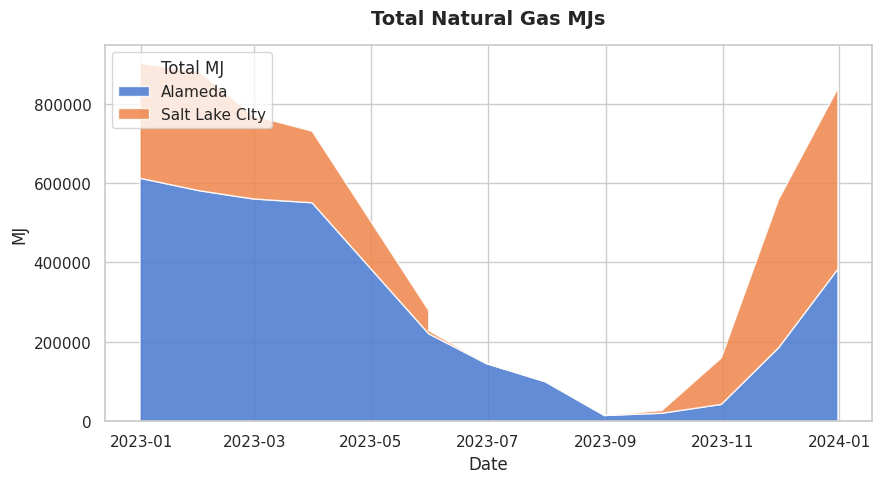

In [ ]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_MJ['date'],
    merged_MJ["al_MJ"], merged_MJ["slc_MJ"],
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas MJs", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Total MJ", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/na_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()


In [ ]:
#subtract 430 green therms offset * 105.5056 MJ/therms = 45367
# 1. Reset and make a clean copy
merged_MJ_offset = merged_MJ.copy()

# 2. Force the subtraction explicitly using .loc
merged_MJ_offset.loc[:, 'slc_MJ'] = merged_MJ_offset['slc_MJ'] - 45367

# 3. Print a quick comparison to PROVE it subtracted
print("Original first value:", merged_MJ['slc_MJ'].iloc[0])
print("New offset value:   ", merged_MJ_offset['slc_MJ'].iloc[0])

# 4. Display dataframe
merged_MJ_offset

Original first value: 289612.87200000003
New offset value:    244245.87200000003


,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,al_MJ,slc_MJ,total_DK,Total_MJ
0,2022-12-31,39986.6224,43573.8128,206052.4368,0.0000,613198.5472,244245.8720,902811.4192,902811.4192
1,2023-01-31,40408.6448,54440.8896,204469.8528,0.0000,581863.3840,253952.3872,881182.7712,881182.7712
2,2023-02-28,34183.8144,59399.6528,116161.6656,0.0000,561184.2864,164378.1328,770929.4192,770929.4192
3,2023-03-31,28275.5008,50220.6656,101918.4096,0.0000,551477.7712,135047.5760,731892.3472,731892.3472
4,2023-05-31,8440.4480,8545.9536,41569.2064,0.0000,221561.7600,13188.6080,280117.3680,280117.3680
5,2023-05-31,422.0224,105.5056,7490.8976,0.0000,221561.7600,-37348.5744,229580.1856,229580.1856
6,2023-06-30,0.0000,105.5056,0.0000,0.0000,146863.7952,-45261.4944,146969.3008,146969.3008
7,2023-07-31,0.0000,211.0112,0.0000,0.0000,100863.3536,-45155.9888,101074.3648,101074.3648
8,2023-08-31,0.0000,105.5056,0.0000,0.0000,15720.3344,-45261.4944,15825.8400,15825.8400
9,2023-09-30,5802.8080,0.0000,1160.5616,0.0000,21523.1424,-38403.6304,28486.5120,28486.5120


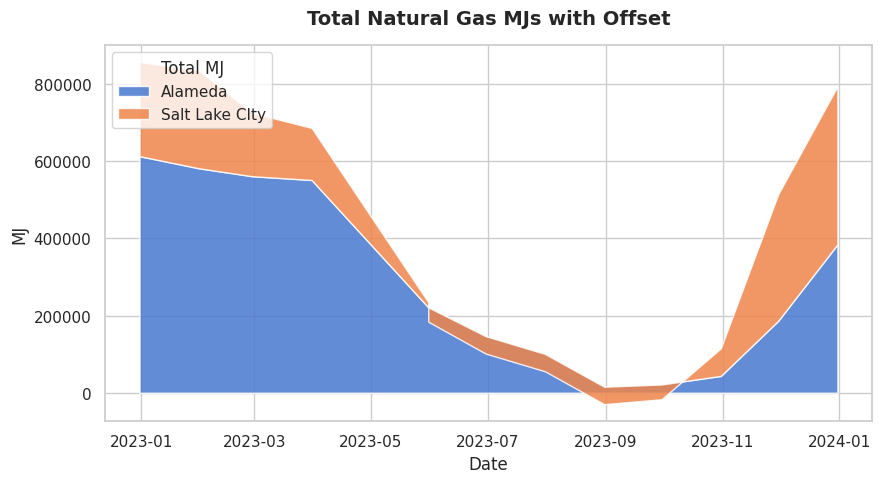

In [ ]:
# "Total Natural Gas MJs with Offset"
# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_MJ_offset['date'],
    merged_MJ_offset["al_MJ"], merged_MJ_offset["slc_MJ"],
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas MJs with Offset", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Total MJ", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/na_stacked_chart_offset.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()

#### Now we convert this into greenhouse gases

In [ ]:
#kg/DK
co2_nat_gas_factor_2023 = ghg_2023.iloc[36:37, 4:5]
co2_nat_gas_factor_2023

,Unnamed: 4
36,53.06


In [ ]:

# in kg CO2 per mmBtu or kg/DK so we divide the co2 factor by 1000 to get MT/DK
co2_nat_gas_factor_2023_MT=co2_nat_gas_factor_2023/1000
co2_nat_gas_factor_2023_MT

,Unnamed: 4
36,0.05306


In [ ]:
#co2_nat_gas_factor_2022 = ghg_2022.iloc[36:37, 4:5]
#co2_nat_gas_factor_2022
# in kg CO2 per mmBtu or kg/DK so we divide the co2 factor by 1000


In [ ]:
#merged_dk = merged_dk.rename(columns={'dk_value':'al_dk'})

In [ ]:
numeric_cols = merged_dk.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['852_S_500_W',
 '860_S_500_W',
 '864_S_500',
 '866_S_500_W',
 'al_DK',
 'slc_DK',
 'total_DK']

In [ ]:
# 1. Force the factor DataFrame into a single, raw numeric value
# This extracts the number out of the first row and first column
raw_factor = float(co2_nat_gas_factor_2023_MT.to_numpy().flatten()[0])

# 2. Recalculate your numeric columns list fresh
numeric_cols = merged_dk.select_dtypes(include=['number']).columns.tolist()

# 3. Create the list of new names
suffix = '_co2'
new_cols = [str(col) + suffix for col in numeric_cols]

# 4. Perform the math safely using our clean raw number
for orig_col, new_col in zip(numeric_cols, new_cols):
    merged_dk[new_col] = merged_dk[orig_col] * raw_factor

merged_dk = merged_dk.rename(columns={"Total_mmBtu_co2":"total_co2"})
# 5. Save and view
ghg_co2e_2023 = merged_dk.copy()
ghg_co2e_2023



,date,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,al_DK,slc_DK,total_DK,852_S_500_W_co2,860_S_500_W_co2,864_S_500_co2,866_S_500_W_co2,al_DK_co2,slc_DK_co2,total_DK_co2
0,2022-12-31,37.9,41.3,195.3,0.0,581.2,274.5,855.7,2.010974,2.191378,10.362618,0.000000,30.838472,14.564970,45.403442
1,2023-01-31,38.3,51.6,193.8,0.0,551.5,283.7,835.2,2.032198,2.737896,10.283028,0.000000,29.262590,15.053122,44.315712
2,2023-02-28,32.4,56.3,110.1,0.0,531.9,198.8,730.7,1.719144,2.987278,5.841906,0.000000,28.222614,10.548328,38.770942
3,2023-03-31,26.8,47.6,96.6,0.0,522.7,171.0,693.7,1.422008,2.525656,5.125596,0.000000,27.734462,9.073260,36.807722
4,2023-05-31,8.0,8.1,39.4,0.0,210.0,55.5,265.5,0.424480,0.429786,2.090564,0.000000,11.142600,2.944830,14.087430
5,2023-05-31,0.4,0.1,7.1,0.0,210.0,7.6,217.6,0.021224,0.005306,0.376726,0.000000,11.142600,0.403256,11.545856
6,2023-06-30,0.0,0.1,0.0,0.0,139.2,0.1,139.3,0.000000,0.005306,0.000000,0.000000,7.385952,0.005306,7.391258
7,2023-07-31,0.0,0.2,0.0,0.0,95.6,0.2,95.8,0.000000,0.010612,0.000000,0.000000,5.072536,0.010612,5.083148
8,2023-08-31,0.0,0.1,0.0,0.0,14.9,0.1,15.0,0.000000,0.005306,0.000000,0.000000,0.790594,0.005306,0.795900
9,2023-09-30,5.5,0.0,1.1,0.0,20.4,6.6,27.0,0.291830,0.000000,0.058366,0.000000,1.082424,0.350196,1.432620


In [ ]:
ghg_co2e_2023_offset = ghg_co2e_2023["slc_DK_co2"] - (43 * raw_factor)
ghg_co2e_2023_offset


,slc_DK_co2
0,12.283390
1,12.771542
2,8.266748
3,6.791680
4,0.663250
5,-1.878324
6,-2.276274
7,-2.270968
8,-2.276274
9,-1.931384


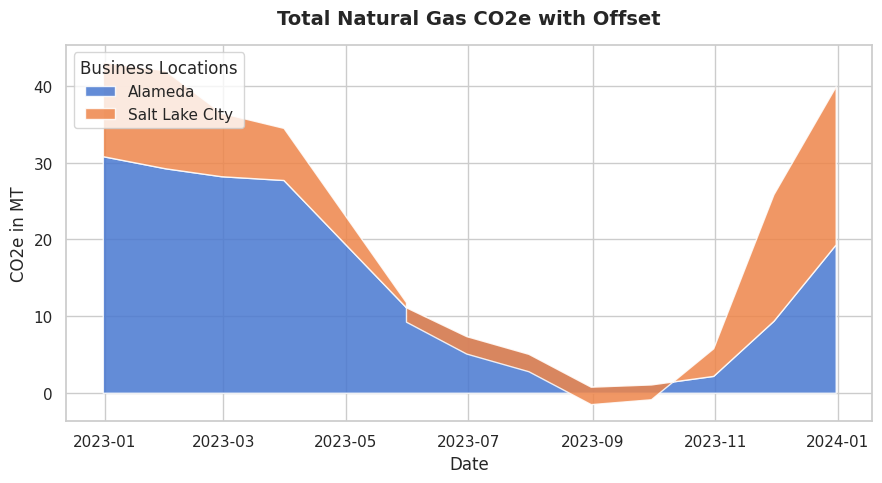

In [ ]:
#"Total Natural Gas CO2e"
# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    ghg_co2e_2023['date'],
    ghg_co2e_2023["al_DK_co2"], ghg_co2e_2023_offset,
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85)


# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas CO2e with Offset", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Business Locations", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/na_CO2_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()


In [ ]:

"""# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_dk['date'],
    merged_dk['al_dk'], merged_dk['slc_total'],
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas MJs", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJs")
ax.legend(title="Business Locations", loc='upper left')

plt.tight_layout()
plt.show()
plt.savefig(
    "na_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)"""

'# 1. Activate Seaborn styling\nsns.set_theme(style="whitegrid")\n\n# 3. Choose a Seaborn color palette\ncolors = sns.color_palette("muted", 3)\n\n# 4. Create the plot\nfig, ax = plt.subplots(figsize=(9, 5))\n\nax.stackplot(\n    merged_dk[\'date\'],\n    merged_dk[\'al_dk\'], merged_dk[\'slc_total\'],\n    labels=[\'Alameda\', \'Salt Lake CIty\'],\n    colors=colors,\n    alpha=0.85\n)\n\n# 5. Clean up annotations using Matplotlib\nax.set_title("Total Natural Gas MJs", fontsize=14, fontweight=\'bold\', pad=15)\nax.set_xlabel("Date")\nax.set_ylabel("MJs")\nax.legend(title="Business Locations", loc=\'upper left\')\n\nplt.tight_layout()\nplt.show()\nplt.savefig(\n    "na_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)\n    dpi=300,  # High resolution for crisp printing/presentations\n    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels\n)'

In [ ]:
#create a ne excel file called outputs and put the merged dk dataframe onto a tab called 2023 Scope 1
file_path = r'outputs/2023_Scope_1.xlsx'

# 2. FORCE write mode ('w') to overwrite the corrupted file completely
with pd.ExcelWriter(file_path, mode='w') as writer:
    merged_dk.to_excel(writer, sheet_name='2023 Scope 1', index=False)



# Scope 2 Emissions

### Electricity

#### Let's create a dataframe for Alameda HQ's Electricity Usage

In [ ]:
# Directory path configurations
pdf_directory = "Alameda_Electric only_AMP"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Regular expressions for cleaning and metric tracking
cid_pattern = r"\(cid:(\d+)\)"
kwh_regex = r"([\d,.]+)\s*kWh"

parsed_rows = []

def decode_cid_text(text):
    """
    Finds all occurrences of (cid:XXX) in a string and
    converts the decimal number back into a readable character.
    """
    if not text:
        return ""

    def replace_cid(match):
        cid_val = int(match.group(1))
        try:
            return chr(cid_val)
        except ValueError:
            return match.group(0)  # Return unchanged if it cannot map

    return re.sub(cid_pattern, replace_cid, text)


# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    extracted_floats = []

    # Extract only the first 6 characters for the clean prefix
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6]
    variable_name = f"{short_prefix}"

    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                raw_text = page.extract_text() or ""
                # CRITICAL STEP: Convert CIDs to real numbers and letters
                clean_page_text = decode_cid_text(raw_text)
                full_text += clean_page_text + "\n"

        # Flatten spaces/tabs to normalize formatting differences
        full_text = re.sub(r'[ \t]+', ' ', full_text)

        # Run your standard pattern against the newly translated clean text string
        matches = re.findall(kwh_regex, full_text, re.IGNORECASE)
        for match in matches:
            clean_match = match.replace(",", "")
            extracted_floats.append(float(clean_match))

        # Total sum of kWh, or fall back to 2.5 if empty
        total_kwh = sum(extracted_floats) if extracted_floats else 2.5

        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_kwh

        # Append data as a dictionary row
        parsed_rows.append({
            "variable_name": variable_name,
            "kwh_value": total_kwh
        })

    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_electricity_al = pd.DataFrame(parsed_rows)


In [ ]:
# change the invoice_prefix to a date
df_electricity_al['variable_name'] = pd.to_datetime(df_electricity_al['variable_name'], format='%y%m%d')

df_electricity_al = df_electricity_al.rename(columns={"variable_name":"date","kwh_value":"al_kWh"})
df_electricity_al

,date,al_kWh
0,2022-12-27,22840.0
1,2023-01-24,20320.0
2,2023-02-21,19600.0
3,2023-03-21,20600.0
4,2023-04-19,19880.0
5,2023-05-23,15520.0
6,2023-06-20,12960.0
7,2023-07-19,12240.0
8,2023-08-21,11080.0
9,2023-09-18,11160.0


In [ ]:
df_electricity_al = df_electricity_al.sort_values(by="date")
df_electricity_al

,date,al_kWh
0,2022-12-27,22840.0
1,2023-01-24,20320.0
2,2023-02-21,19600.0
3,2023-03-21,20600.0
4,2023-04-19,19880.0
5,2023-05-23,15520.0
6,2023-06-20,12960.0
7,2023-07-19,12240.0
8,2023-08-21,11080.0
9,2023-09-18,11160.0


In [ ]:




# 1. Convert your date column to datetime objects safely
df_electricity_al['date'] = pd.to_datetime(df_electricity_al['date'])

# 2. Shift to the 1st of the month, then subtract exactly 1 day.
# This bypasses MonthEnd logic entirely.
df_electricity_al['date'] = df_electricity_al['date'].dt.to_period('M').dt.to_timestamp() - pd.Timedelta(days=1)



In [ ]:
df_electricity_al

,date,al_kWh
0,2022-11-30,22840.0
1,2022-12-31,20320.0
2,2023-01-31,19600.0
3,2023-02-28,20600.0
4,2023-03-31,19880.0
5,2023-04-30,15520.0
6,2023-05-31,12960.0
7,2023-06-30,12240.0
8,2023-07-31,11080.0
9,2023-08-31,11160.0


In [ ]:
df_electricity_al.to_excel('outputs/alameda_electricity_data.xlsx', index=False)

#### Let's create a dataframe for Salt Lake City's Electricity Usage

In [ ]:


"""# Directory path configurations
pdf_directory = "SLC_Electric_RMP"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

kwh_regex = r"(?:29|1\.0)\s+([\d,]+)\s*kwh"
parsed_rows = []  # Reset the collection list

# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    extracted_floats = []

    # Extract only the first 6 characters for the clean prefix
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6]
    variable_name = f"{short_prefix}"

    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                raw_text = page.extract_text() or ""

                # Process line-by-line
                for line in raw_text.splitlines():
                    # Normalize spaces/tabs for the current line
                    clean_line = re.sub(r'[ \t]+', ' ', line).strip()

                    # Search for the pattern in the current line
                    if re.search(kwh_regex, clean_line, re.IGNORECASE):
                        # --- DISPLAY THE MATCHING LINE ---
                        print(f"[{short_prefix}] Matched Line: {clean_line}")

                        # Extract the float values from the matched line
                        matches = re.findall(kwh_regex, clean_line, re.IGNORECASE)
                        for match in matches:
                            clean_match = match.replace(",", "")
                            extracted_floats.append(float(clean_match))

        # Deduplicate values found in this PDF
        extracted_floats = list(set(extracted_floats))

        # Total sum of kWh, or fall back to 2.5 if empty
        total_kwh = sum(extracted_floats) if extracted_floats else 2.5

        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_kwh

        # 1. Start building the row dictionary
        row_dict = {
            "date": variable_name,
            "total_kwh_value": total_kwh
        }

        # 2. Unpack the list items into separate keys dynamically
        for i, val in enumerate(extracted_floats, start=1):
            row_dict[f"extracted_kwh_{i}"] = val

        # 3. Append the expanded dictionary to your rows list
        parsed_rows.append(row_dict)

    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME ---
df_electricity_slc = pd.DataFrame(parsed_rows)"""

'# Directory path configurations\npdf_directory = "SLC_Electric_RMP"\npdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")\n\nkwh_regex = r"(?:29|1\\.0)\\s+([\\d,]+)\\s*kwh"\nparsed_rows = []  # Reset the collection list\n\n# Loop through all matching PDFs found in the directory\nfor pdf_path in glob.glob(pdf_pattern):\n    base_name = os.path.basename(pdf_path)\n    extracted_floats = []\n\n    # Extract only the first 6 characters for the clean prefix\n    file_prefix = re.sub(r\'\\.pdf$\', \'\', base_name, flags=re.IGNORECASE).replace(\' \', \'_\')\n    short_prefix = file_prefix[:6]\n    variable_name = f"{short_prefix}"\n\n    try:\n        with pdfplumber.open(pdf_path) as pdf:\n            for page in pdf.pages:\n                raw_text = page.extract_text() or ""\n\n                # Process line-by-line\n                for line in raw_text.splitlines():\n                    # Normalize spaces/tabs for the current line\n                    clean_line = re.sub(r\'[ \t]+

In [ ]:
# Directory path configurations
pdf_directory = "SLC_Electric_RMP"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

kwh_regex = r"(?:29|1\.0)\s+([\d,]+)\s*kwh"
parsed_rows = []  # Explicitly reset or ensure your collection list is ready

# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    extracted_floats = []

    # Extract only the first 6 characters for the clean prefix
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6]
    variable_name = f"{short_prefix}"

    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                raw_text = page.extract_text() or ""
                full_text += raw_text + "\n"

        # Flatten spaces/tabs to normalize formatting differences
        full_text = re.sub(r'[ \t]+', ' ', full_text)

        matches = re.findall(kwh_regex, full_text, re.IGNORECASE)
        for match in matches:
            clean_match = match.replace(",", "")
            extracted_floats.append(float(clean_match))

        extracted_floats = list(set(extracted_floats))
        print(f"{short_prefix}: {extracted_floats}")


        # Total sum of kWh, or fall back to 2.5 if empty
        total_kwh = sum(extracted_floats) if extracted_floats else 2.5

        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_kwh

       # 1. Start building the row dictionary
        row_dict = {
            "date": variable_name,
            "total_kwh_value": total_kwh
        }

        # 2. FIX: Unpack the list items into separate keys dynamically
        for i, val in enumerate(extracted_floats, start=1):
            row_dict[f"extracted_kwh_{i}"] = val

        # 3. Append the expanded dictionary straight to your rows list
        parsed_rows.append(row_dict)

    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_electricity_slc = pd.DataFrame(parsed_rows)

221230: [2608.0, 8993.0, 741.0, 4110.0]
230131: [811.0, 4132.0, 2909.0, 7395.0]
230301: [4408.0, 760.0, 6952.0, 2645.0]
230330: [2088.0, 6899.0, 5157.0, 710.0]
230505: [609.0, 8467.0, 4014.0, 1953.0]
230530: [914.0, 4187.0, 14357.0, 1390.0]
230629: [1304.0, 1576.0, 11948.0, 4159.0]
230807: [2050.0, 4403.0, 23900.0, 1620.0]
230906: [1696.0, 22816.0, 4986.0, 1047.0]
231005: [1163.0, 788.0, 4781.0, 16347.0]
231030: [729.0, 883.0, 9780.0, 4661.0]
231201: [5370.0, 1667.0, 10949.0, 1007.0]
240101: [4466.0, 2050.0, 844.0, 10479.0]


In [ ]:
# Use the DataFrame directly, NOT the bracket selection
df_electricity_slc = df_electricity_slc.sort_values(by="date")
df_electricity_slc

,date,total_kwh_value,extracted_kwh_1,extracted_kwh_2,extracted_kwh_3,extracted_kwh_4
0,221230,16452.0,2608.0,8993.0,741.0,4110.0
1,230131,15247.0,811.0,4132.0,2909.0,7395.0
2,230301,14765.0,4408.0,760.0,6952.0,2645.0
3,230330,14854.0,2088.0,6899.0,5157.0,710.0
4,230505,15043.0,609.0,8467.0,4014.0,1953.0
5,230530,20848.0,914.0,4187.0,14357.0,1390.0
6,230629,18987.0,1304.0,1576.0,11948.0,4159.0
7,230807,31973.0,2050.0,4403.0,23900.0,1620.0
8,230906,30545.0,1696.0,22816.0,4986.0,1047.0
9,231005,23079.0,1163.0,788.0,4781.0,16347.0


In [ ]:
columns={"total_kwh_value":"slc_total_kwh","extracted_kwh_1":"852_S_500_W","extracted_kwh_2":"860_S_500_W", "extracted_kwh_3":"864_S_500", "extracted_kwh_4":"866_S_500_W"}
df_electricity_slc= df_electricity_slc.rename(columns=columns)
df_electricity_slc

,date,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,221230,16452.0,2608.0,8993.0,741.0,4110.0
1,230131,15247.0,811.0,4132.0,2909.0,7395.0
2,230301,14765.0,4408.0,760.0,6952.0,2645.0
3,230330,14854.0,2088.0,6899.0,5157.0,710.0
4,230505,15043.0,609.0,8467.0,4014.0,1953.0
5,230530,20848.0,914.0,4187.0,14357.0,1390.0
6,230629,18987.0,1304.0,1576.0,11948.0,4159.0
7,230807,31973.0,2050.0,4403.0,23900.0,1620.0
8,230906,30545.0,1696.0,22816.0,4986.0,1047.0
9,231005,23079.0,1163.0,788.0,4781.0,16347.0


In [ ]:
df_electricity_slc['date'] = pd.to_datetime(df_electricity_slc['date'], format='%y%m%d')
df_electricity_slc

,date,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,2022-12-30,16452.0,2608.0,8993.0,741.0,4110.0
1,2023-01-31,15247.0,811.0,4132.0,2909.0,7395.0
2,2023-03-01,14765.0,4408.0,760.0,6952.0,2645.0
3,2023-03-30,14854.0,2088.0,6899.0,5157.0,710.0
4,2023-05-05,15043.0,609.0,8467.0,4014.0,1953.0
5,2023-05-30,20848.0,914.0,4187.0,14357.0,1390.0
6,2023-06-29,18987.0,1304.0,1576.0,11948.0,4159.0
7,2023-08-07,31973.0,2050.0,4403.0,23900.0,1620.0
8,2023-09-06,30545.0,1696.0,22816.0,4986.0,1047.0
9,2023-10-05,23079.0,1163.0,788.0,4781.0,16347.0


In [ ]:
from pandas.tseries.offsets import MonthEnd

def nearest_month_end(date):
    # Check if the day is in the first half of the month (<= 15)
    # If yes, go to the end of the previous month. If no, go to the end of the current month.
    if date.day <= 15:
        # Subtract from the first of the month, then find month end
        return date.replace(day=1) - MonthEnd(1)
    else:
        # Find month end for the current month
        return date + MonthEnd(0)


# --- HOW TO APPLY TO YOUR DATAFRAME ---

# 1. Convert your date column to datetime objects first
df_electricity_slc['date'] = pd.to_datetime(df_electricity_slc['date'])

# 2. Apply the function to the date column
df_electricity_slc['date'] = df_electricity_slc['date'].apply(nearest_month_end)



In [ ]:
df_electricity_slc["date"]


,date
0,2022-12-31
1,2023-01-31
2,2023-02-28
3,2023-03-31
4,2023-04-30
5,2023-05-31
6,2023-06-30
7,2023-07-31
8,2023-08-31
9,2023-09-30


In [ ]:
df_electricity_slc = df_electricity_slc.sort_values(by="date")
df_electricity_slc

,date,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W
0,2022-12-31,16452.0,2608.0,8993.0,741.0,4110.0
1,2023-01-31,15247.0,811.0,4132.0,2909.0,7395.0
2,2023-02-28,14765.0,4408.0,760.0,6952.0,2645.0
3,2023-03-31,14854.0,2088.0,6899.0,5157.0,710.0
4,2023-04-30,15043.0,609.0,8467.0,4014.0,1953.0
5,2023-05-31,20848.0,914.0,4187.0,14357.0,1390.0
6,2023-06-30,18987.0,1304.0,1576.0,11948.0,4159.0
7,2023-07-31,31973.0,2050.0,4403.0,23900.0,1620.0
8,2023-08-31,30545.0,1696.0,22816.0,4986.0,1047.0
9,2023-09-30,23079.0,1163.0,788.0,4781.0,16347.0


In [ ]:
df_electricity_slc.to_excel('outputs/slc_electricity_data.xlsx', index=False)

In [ ]:
df_electricity = df_electricity_al.merge(df_electricity_slc, on="date")
df_electricity["total_kWh"] = df_electricity["al_kWh"] + df_electricity["slc_total_kwh"]
df_electricity["al_MWh"]= df_electricity["al_kWh"]/1000
# 2. Convert the specific hardware/sensor columns in-place
sensor_cols = ["852_S_500_W", "860_S_500_W", "864_S_500", "866_S_500_W"]
df_electricity[sensor_cols] = df_electricity[sensor_cols] / 1000

df_electricity["slc_MWh"] = df_electricity["slc_total_kwh"]/1000
df_electricity["total_MWh"] = df_electricity["al_MWh"] + df_electricity["slc_MWh"]
df_electricity

,date,al_kWh,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,total_kWh,al_MWh,slc_MWh,total_MWh
0,2022-12-31,20320.0,16452.0,2.608,8.993,0.741,4.110,36772.0,20.32,16.452,36.772
1,2023-01-31,19600.0,15247.0,0.811,4.132,2.909,7.395,34847.0,19.60,15.247,34.847
2,2023-02-28,20600.0,14765.0,4.408,0.760,6.952,2.645,35365.0,20.60,14.765,35.365
3,2023-03-31,19880.0,14854.0,2.088,6.899,5.157,0.710,34734.0,19.88,14.854,34.734
4,2023-04-30,15520.0,15043.0,0.609,8.467,4.014,1.953,30563.0,15.52,15.043,30.563
5,2023-05-31,12960.0,20848.0,0.914,4.187,14.357,1.390,33808.0,12.96,20.848,33.808
6,2023-06-30,12240.0,18987.0,1.304,1.576,11.948,4.159,31227.0,12.24,18.987,31.227
7,2023-07-31,11080.0,31973.0,2.050,4.403,23.900,1.620,43053.0,11.08,31.973,43.053
8,2023-08-31,11160.0,30545.0,1.696,22.816,4.986,1.047,41705.0,11.16,30.545,41.705
9,2023-09-30,10880.0,23079.0,1.163,0.788,4.781,16.347,33959.0,10.88,23.079,33.959


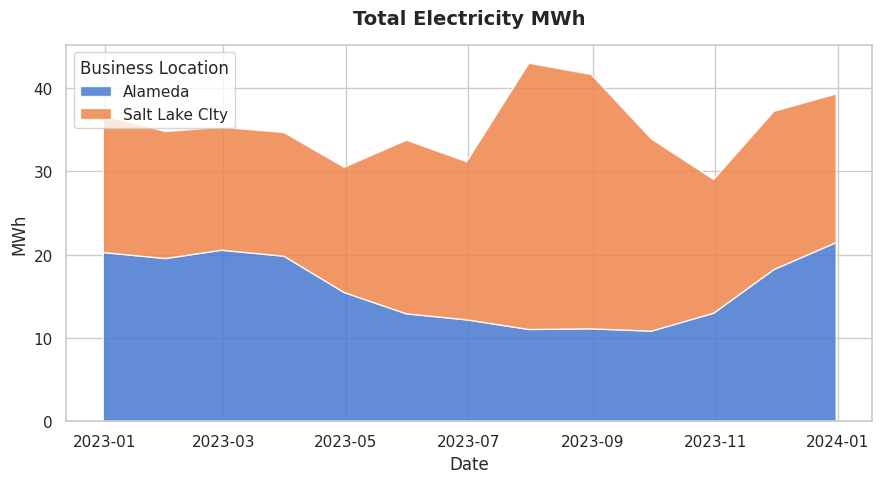

In [ ]:


# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    df_electricity['date'],
    df_electricity["al_MWh"],
    df_electricity['slc_MWh'],
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Electricity MWh", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MWh")
ax.legend(title="Business Location", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/elec_MWh_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()


In [ ]:
#convert MWh to MJs

df_electricity_mj= df_electricity[["852_S_500_W","860_S_500_W","864_S_500","866_S_500_W","al_MWh","slc_MWh","total_MWh"]] * 3600
df_electricity_mj = df_electricity_mj.rename(columns={"al_MWh":"al_elec_mj","slc_MWh":"slc_elec_mj","total_MWh":"total_elec_mj"})
df_electricity_mj["date"] = df_electricity["date"]

df_electricity_mj

,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,al_elec_mj,slc_elec_mj,total_elec_mj,date
0,9388.8,32374.8,2667.6,14796.0,73152.0,59227.2,132379.2,2022-12-31
1,2919.6,14875.2,10472.4,26622.0,70560.0,54889.2,125449.2,2023-01-31
2,15868.8,2736.0,25027.2,9522.0,74160.0,53154.0,127314.0,2023-02-28
3,7516.8,24836.4,18565.2,2556.0,71568.0,53474.4,125042.4,2023-03-31
4,2192.4,30481.2,14450.4,7030.8,55872.0,54154.8,110026.8,2023-04-30
5,3290.4,15073.2,51685.2,5004.0,46656.0,75052.8,121708.8,2023-05-31
6,4694.4,5673.6,43012.8,14972.4,44064.0,68353.2,112417.2,2023-06-30
7,7380.0,15850.8,86040.0,5832.0,39888.0,115102.8,154990.8,2023-07-31
8,6105.6,82137.6,17949.6,3769.2,40176.0,109962.0,150138.0,2023-08-31
9,4186.8,2836.8,17211.6,58849.2,39168.0,83084.4,122252.4,2023-09-30


In [ ]:
total_mjs_dec_2022_december_2023_df = df_electricity_mj[["al_elec_mj","slc_elec_mj"]]
total_mjs_dec_2022_december_2023_df

,al_elec_mj,slc_elec_mj
0,73152.0,59227.2
1,70560.0,54889.2
2,74160.0,53154.0
3,71568.0,53474.4
4,55872.0,54154.8
5,46656.0,75052.8
6,44064.0,68353.2
7,39888.0,115102.8
8,40176.0,109962.0
9,39168.0,83084.4


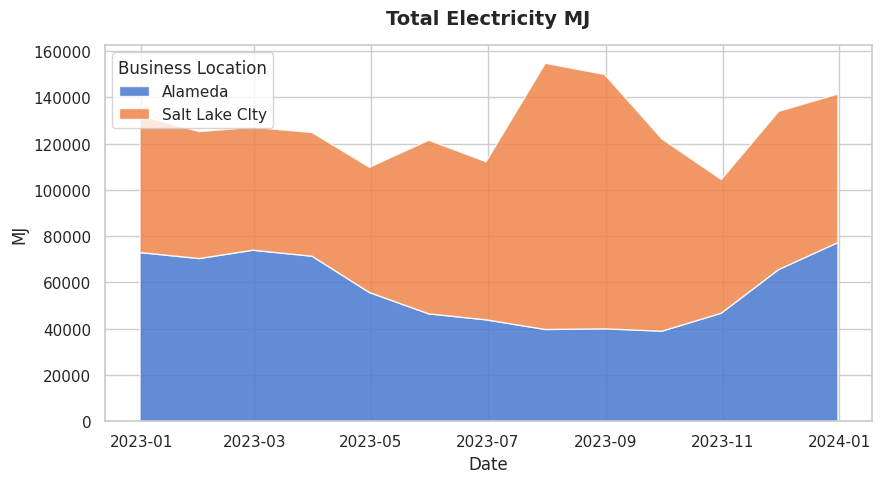

In [ ]:
#Total_mmBtu


# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    df_electricity_mj['date'],
    total_mjs_dec_2022_december_2023_df['al_elec_mj'],
    total_mjs_dec_2022_december_2023_df['slc_elec_mj'],
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Electricity MJ", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Business Location", loc='upper left')

plt.tight_layout()
plt.savefig(
    "elec_MJ_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()


#### Total MJs for both Natural Gas and Electricity

In [ ]:
total_al_MJ = df_electricity_mj["al_elec_mj"]+ merged_MJ["al_MJ"],   # First data layer (13 values)
total_slc_MJ = df_electricity_mj["slc_elec_mj"] + merged_MJ["slc_MJ"]


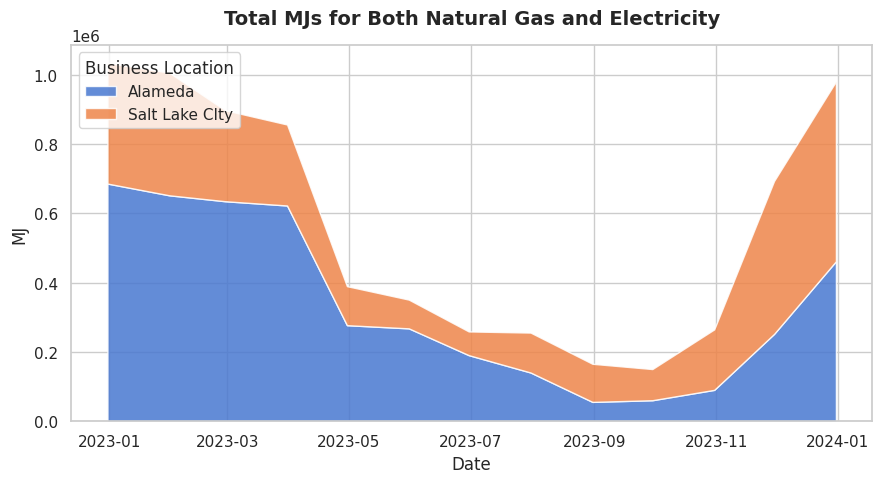

In [ ]:
#Total MJs of Natural Gas and Electricity


# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    df_electricity_mj['date'],
    total_al_MJ,
    total_slc_MJ,
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total MJs for Both Natural Gas and Electricity", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Business Location", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/total_MJs_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()




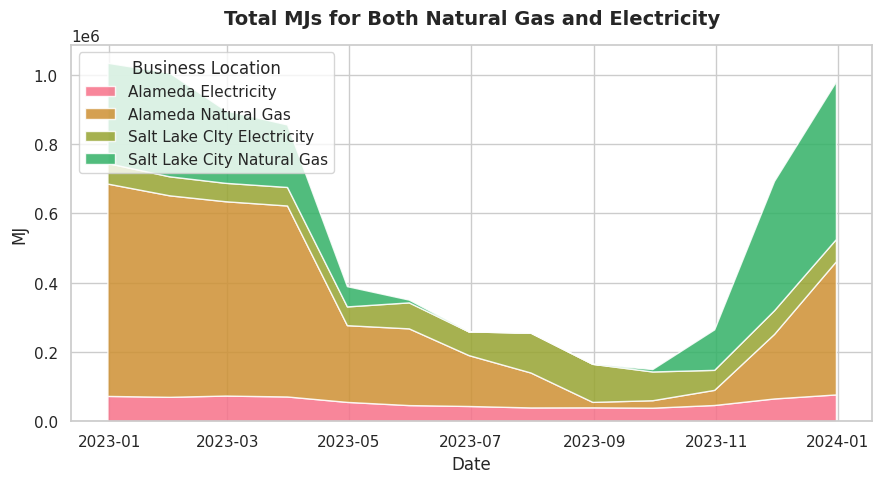

In [ ]:
#Total MJs of Natural Gas and Electricity divided by natural gas and electricity


# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    df_electricity_mj['date'],
    total_mjs_dec_2022_december_2023_df['al_elec_mj'],merged_MJ["al_MJ"],
    total_mjs_dec_2022_december_2023_df['slc_elec_mj'],merged_MJ["slc_MJ"],
    labels=['Alameda Electricity', "Alameda Natural Gas", 'Salt Lake CIty Electricity', "Salt Lake City Natural Gas"],
    colors=sns.color_palette("husl", 8),
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total MJs for Both Natural Gas and Electricity", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Business Location", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/total_MJs_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()



In [ ]:
total_slc_MJ_offset = total_mjs_dec_2022_december_2023_df['slc_elec_mj']

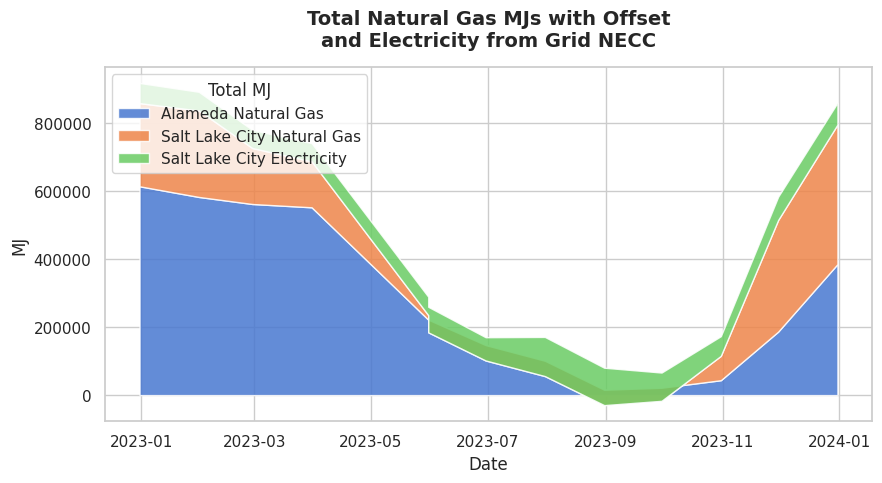

In [ ]:

#Total MJs of Natural Gas and Electricity


# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_MJ_offset['date'],
    merged_MJ_offset["al_MJ"], merged_MJ_offset["slc_MJ"],
    total_mjs_dec_2022_december_2023_df['slc_elec_mj'],
    labels=["Alameda Natural Gas",'Salt Lake City Natural Gas',"Salt Lake City Electricity"],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas MJs with Offset\nand Electricity from Grid NECC", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(title="Total MJ", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/total_MJ_al_slc_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()
## I had a hard time figuring out that the MJ offset actually pulls down the electrical MJs

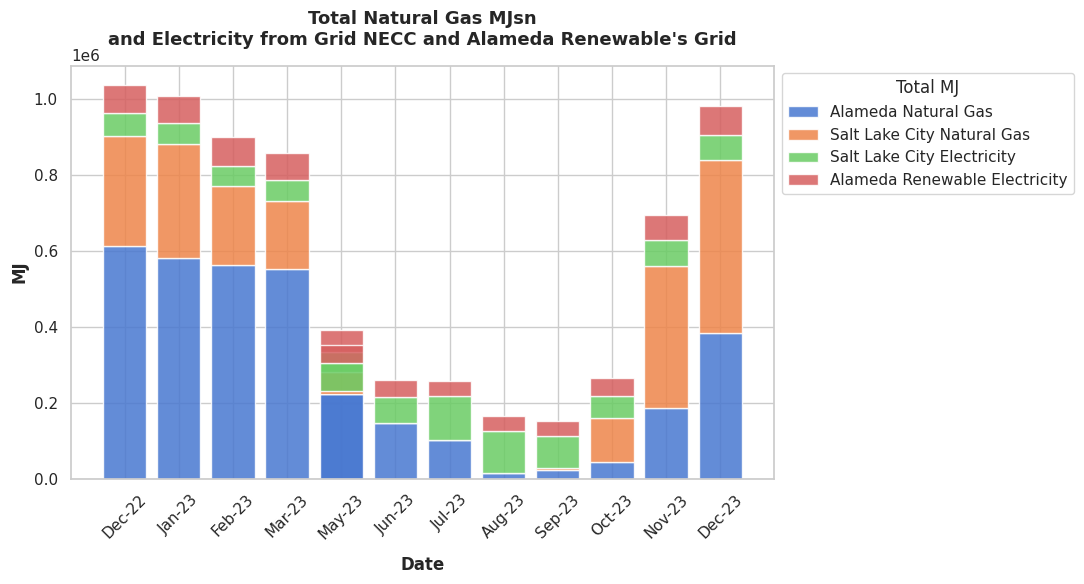

In [ ]:

# Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 1. Clean the date strings to ensure safe categorical spacing
# Slicing to matching lengths if needed (assuming 13 months based on Dec 22 - Dec 23)
x = pd.to_datetime(merged_MJ_offset['date']).dt.strftime('%b-%y').values[:13]

# 2. Extract aligned data arrays from your two source data frames
y1 = merged_MJ["al_MJ"].values[:13]
y2 = merged_MJ["slc_MJ"].values[:13]
y3 = total_mjs_dec_2022_december_2023_df['slc_elec_mj'].values[:13]
y4 = total_mjs_dec_2022_december_2023_df['al_elec_mj'].values[:13]

# Generate a color palette for 4 distinct streams
colors = sns.color_palette("muted", 4)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(11, 6))
bar_width = 0.8  # Perfect proportional width for text/string categories

# 4. Plot bars with sequential bottom stacking
b1 = ax.bar(x, y1, width=bar_width, label="Alameda Natural Gas", color=colors[0], alpha=0.85)
b2 = ax.bar(x, y2, bottom=y1, width=bar_width, label="Salt Lake City Natural Gas", color=colors[1], alpha=0.85)
b3 = ax.bar(x, y3, bottom=y1 + y2, width=bar_width, label="Salt Lake City Electricity", color=colors[2], alpha=0.85)
b4 = ax.bar(x, y4, bottom=y1 + y2 + y3, width=bar_width, label="Alameda Renewable Electricity", color=colors[3], alpha=0.85)

# 5. Clean up annotations and format
ax.set_title("Total Natural Gas MJsn\nand Electricity from Grid NECC and Alameda Renewable's Grid", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontweight='bold', labelpad=10)
ax.set_ylabel("MJ", fontweight='bold')

# Rotate ticks for breathing room
plt.xticks(rotation=45)

# Place the legend securely to the right out of the data's way
ax.legend(title="Total MJ", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save and show
plt.savefig("outputs/total_MJ_al_slc_stacked_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

#without the offset

#### electricity CO2

Alameda has it's own grid from 100% renewable sources

In [ ]:
electricity_co2_2022 = ghg_2022.iloc[311:339, 2:4]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2022.rename(columns={'Unnamed: 2': 'eGRID subregion', 'Unnamed: 3': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2022

,eGRID subregion,CO2 Factor lb/MWh
311,AKGD (ASCC Alaska Grid),1097.6
312,AKMS (ASCC Miscellaneous),534.1
313,AZNM (WECC Southwest),846.6
314,CAMX (WECC California),513.5
315,ERCT (ERCOT All),818.6
316,FRCC (FRCC All),835.1
317,HIMS (HICC Miscellaneous),1143.2
318,HIOA (HICC Oahu),1653
319,MROE (MRO East),1526.4
320,MROW (MRO West),979.5


In [ ]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2022 = electricity_co2_2022.set_index('eGRID subregion')

#row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
#al_co2_factor_2022 = electricity_co2_2022.iloc[row_idx, 0]

row_idx = electricity_co2_2022.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2022 = electricity_co2_2022.iloc[row_idx, 0]

#print("California 2022 CO2 emissions factor: ",al_co2_factor_2022)
print("Utah 2022 CO2 emissions factor: ",slc_co2_factor_2022)

Utah 2022 CO2 emissions factor:  600


In [ ]:
electricity_co2_2023 = ghg_2023.iloc[323:351, 3:5]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2023.rename(columns={'Unnamed: 3': 'eGRID subregion', 'Unnamed: 4': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2023

,eGRID subregion,CO2 Factor lb/MWh
323,AKGD (ASCC Alaska Grid),1067.7
324,AKMS (ASCC Miscellaneous),485.2
325,AZNM (WECC Southwest),819.7
326,CAMX (WECC California),531.7
327,ERCT (ERCOT All),813.6
328,FRCC (FRCC All),832.9
329,HIMS (HICC Miscellaneous),1134.4
330,HIOA (HICC Oahu),1633.1
331,MROE (MRO East),1582.1
332,MROW (MRO West),995.8


In [ ]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2023 = electricity_co2_2023.set_index('eGRID subregion')

#row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
#al_co2_factor_2023 = electricity_co2_2023.iloc[row_idx, 0]

row_idx = electricity_co2_2023.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2023 = electricity_co2_2023.iloc[row_idx, 0]

#print("California 2023 CO2 emissions factor: ",al_co2_factor_2023)
print("Utah 2023 CO2 emissions factor: ",slc_co2_factor_2023)

Utah 2023 CO2 emissions factor:  634.6


In [ ]:
electricity_co2_2024 = ghg_2024.iloc[331:351, 3:5]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2024.rename(columns={'Unnamed: 3': 'eGRID subregion', 'Unnamed: 4': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2024

,eGRID subregion,CO2 Factor lb/MWh
331,MROE (MRO East),1582.1
332,MROW (MRO West),995.8
333,NEWE (NPCC New England),539.4
334,NWPP (WECC Northwest),634.6
335,NYCW (NPCC NYC/Westchester),816.8
336,NYLI (NPCC Long Island),1210.9
337,NYUP (NPCC Upstate NY),233.1
338,PRMS (Puerto Rico Miscellaneous),1558
339,RFCE (RFC East),672.8
340,RFCM (RFC Michigan),1214.1


In [ ]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2024 = electricity_co2_2024.set_index('eGRID subregion')

row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
al_co2_factor_2024 = electricity_co2_2024.iloc[row_idx, 0]

row_idx = electricity_co2_2023.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2024 = electricity_co2_2024.iloc[row_idx, 0]

print("California 2024 CO2 emissions factor: ",al_co2_factor_2024)
print("Utah 2024 CO2 emissions factor: ",slc_co2_factor_2024)

California 2024 CO2 emissions factor:  634.6
Utah 2024 CO2 emissions factor:  1158.9


In [ ]:
"""# 1. Define your factors in a dictionary
co2_factors_al = {
    2022: al_co2_factor_2022,
    2023: al_co2_factor_2023,
    2024: al_co2_factor_2024
}

# 2. Extract the year
years = df_electricity['date'].dt.year

# 3. Save the actual factor as its own column
df_electricity['al_co2_factor'] = years.map(co2_factors_al)

#df_electricity

# 4. Calculate the final CO2 emissions using the new factor column
df_electricity['co2_lb_al'] = df_electricity["al_MWh"] * df_electricity["al_co2_factor"]
df_electricity"""

'# 1. Define your factors in a dictionary\nco2_factors_al = {\n    2022: al_co2_factor_2022,\n    2023: al_co2_factor_2023,\n    2024: al_co2_factor_2024\n}\n\n# 2. Extract the year\nyears = df_electricity[\'date\'].dt.year\n\n# 3. Save the actual factor as its own column\ndf_electricity[\'al_co2_factor\'] = years.map(co2_factors_al)\n\n#df_electricity\n\n# 4. Calculate the final CO2 emissions using the new factor column\ndf_electricity[\'co2_lb_al\'] = df_electricity["al_MWh"] * df_electricity["al_co2_factor"]\ndf_electricity'

In [ ]:
# 1. Define your factors in a dictionary
co2_factors_slc = {
    2022: slc_co2_factor_2022,
    2023: slc_co2_factor_2023,
    2024: slc_co2_factor_2024
}

# 2. Extract the year
years = df_electricity['date'].dt.year

# 3. Save the actual factor as its own column
df_electricity['slc_co2_factor'] = years.map(co2_factors_slc)

# 4. Calculate the final CO2 emissions using the new factor column
df_electricity['co2_lb_slc'] = df_electricity["slc_MWh"] * df_electricity['slc_co2_factor']
#df_electricity["total_lb_co2"] = df_electricity["co2_lb_al"] + df_electricity["co2_lb_slc"]
df_electricity

,date,al_kWh,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,total_kWh,al_MWh,slc_MWh,total_MWh,slc_co2_factor,co2_lb_slc
0,2022-12-31,20320.0,16452.0,2.608,8.993,0.741,4.110,36772.0,20.32,16.452,36.772,600.0,9871.2000
1,2023-01-31,19600.0,15247.0,0.811,4.132,2.909,7.395,34847.0,19.60,15.247,34.847,634.6,9675.7462
2,2023-02-28,20600.0,14765.0,4.408,0.760,6.952,2.645,35365.0,20.60,14.765,35.365,634.6,9369.8690
3,2023-03-31,19880.0,14854.0,2.088,6.899,5.157,0.710,34734.0,19.88,14.854,34.734,634.6,9426.3484
4,2023-04-30,15520.0,15043.0,0.609,8.467,4.014,1.953,30563.0,15.52,15.043,30.563,634.6,9546.2878
5,2023-05-31,12960.0,20848.0,0.914,4.187,14.357,1.390,33808.0,12.96,20.848,33.808,634.6,13230.1408
6,2023-06-30,12240.0,18987.0,1.304,1.576,11.948,4.159,31227.0,12.24,18.987,31.227,634.6,12049.1502
7,2023-07-31,11080.0,31973.0,2.050,4.403,23.900,1.620,43053.0,11.08,31.973,43.053,634.6,20290.0658
8,2023-08-31,11160.0,30545.0,1.696,22.816,4.986,1.047,41705.0,11.16,30.545,41.705,634.6,19383.8570
9,2023-09-30,10880.0,23079.0,1.163,0.788,4.781,16.347,33959.0,10.88,23.079,33.959,634.6,14645.9334


In [ ]:
#convert from lbs to MT
target_cols = ['co2_lb_slc']

# 2. Update ONLY these columns inside the dataframe (Keep the rest intact!)
df_electricity[target_cols] = df_electricity[target_cols] / 2204.62

df_electricity = df_electricity.rename(columns={'co2_lb_slc': 'co2_MT_slc'})

df_electricity


,date,al_kWh,slc_total_kwh,852_S_500_W,860_S_500_W,864_S_500,866_S_500_W,total_kWh,al_MWh,slc_MWh,total_MWh,slc_co2_factor,co2_MT_slc
0,2022-12-31,20320.0,16452.0,2.608,8.993,0.741,4.110,36772.0,20.32,16.452,36.772,600.0,4.477506
1,2023-01-31,19600.0,15247.0,0.811,4.132,2.909,7.395,34847.0,19.60,15.247,34.847,634.6,4.388850
2,2023-02-28,20600.0,14765.0,4.408,0.760,6.952,2.645,35365.0,20.60,14.765,35.365,634.6,4.250106
3,2023-03-31,19880.0,14854.0,2.088,6.899,5.157,0.710,34734.0,19.88,14.854,34.734,634.6,4.275725
4,2023-04-30,15520.0,15043.0,0.609,8.467,4.014,1.953,30563.0,15.52,15.043,30.563,634.6,4.330128
5,2023-05-31,12960.0,20848.0,0.914,4.187,14.357,1.390,33808.0,12.96,20.848,33.808,634.6,6.001098
6,2023-06-30,12240.0,18987.0,1.304,1.576,11.948,4.159,31227.0,12.24,18.987,31.227,634.6,5.465409
7,2023-07-31,11080.0,31973.0,2.050,4.403,23.900,1.620,43053.0,11.08,31.973,43.053,634.6,9.203430
8,2023-08-31,11160.0,30545.0,1.696,22.816,4.986,1.047,41705.0,11.16,30.545,41.705,634.6,8.792380
9,2023-09-30,10880.0,23079.0,1.163,0.788,4.781,16.347,33959.0,10.88,23.079,33.959,634.6,6.643292


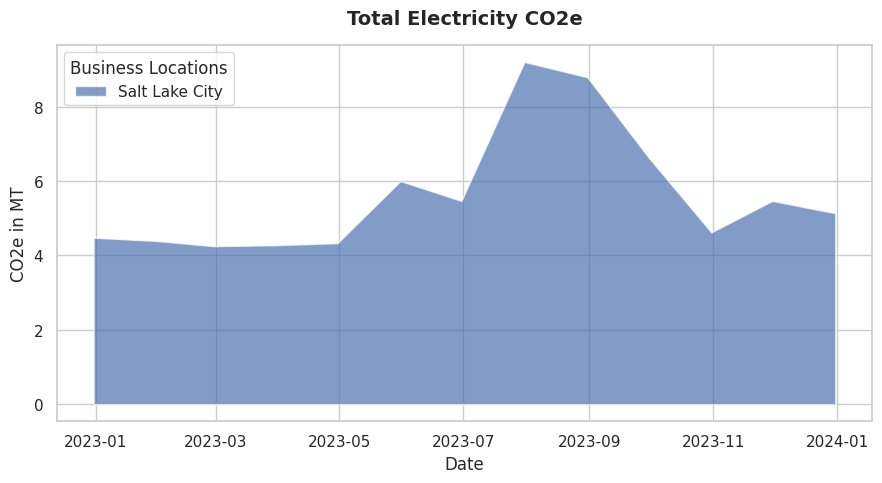

In [ ]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

x_data = df_electricity['date'].squeeze()
y_data = df_electricity['co2_MT_slc'].squeeze()

ax.fill_between(
    x_data,
    y_data,
    label='Salt Lake City',
    alpha=0.7
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Electricity CO2e", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Business Locations", loc='upper left')
plt.savefig(
    "outputs/elec_stacked_chart_co2.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.tight_layout()
plt.show()


In [ ]:

"""#Total MJs of Natural Gas and Electricity

colors=sns.light_palette("purple")

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

merged_MJ_offset_M = merged_MJ_offset.copy()
merged_MJ_offset_M['date'] = merged_MJ_offset_M['date'].dt.to_period('M')
merged_MJ_offset_M_indexed = merged_MJ_offset_M.set_index('date')

merged_MJ_offset_M_indexed[['slc_elec_mj','al_elec_mj']] = total_mjs_dec_2022_december_2023_df[['slc_elec_mj','al_elec_mj']]
# Fix 3: Plot using the correct DataFrame variable name
merged_MJ_offset_M_indexed[["al_MJ","slc_MJ",'slc_elec_mj','al_elec_mj']].plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax)



# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas MJs with Offset\nand Electricity from Grid NECC\nwith Renewable Electricity from Alameda", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("MJ")
ax.legend(
    labels=[
        "Alameda Natural Gas",
        "SLC Natural Gas",
        "SLC Grid Electricity",
        "Alameda Renewable Electricity"
    ],
    title="Total MJ",
    loc='upper left'
)

plt.tight_layout()
plt.savefig(
    "outputs/total_MJ_al_slc_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()
## I had a hard time figuring out that the MJ offset actually pulls down the electrical MJs"""

'#Total MJs of Natural Gas and Electricity\n\ncolors=sns.light_palette("purple")\n\n# 4. Create the plot\nfig, ax = plt.subplots(figsize=(9, 5))\n\nmerged_MJ_offset_M = merged_MJ_offset.copy()\nmerged_MJ_offset_M[\'date\'] = merged_MJ_offset_M[\'date\'].dt.to_period(\'M\')\nmerged_MJ_offset_M_indexed = merged_MJ_offset_M.set_index(\'date\')\n\nmerged_MJ_offset_M_indexed[[\'slc_elec_mj\',\'al_elec_mj\']] = total_mjs_dec_2022_december_2023_df[[\'slc_elec_mj\',\'al_elec_mj\']]\n# Fix 3: Plot using the correct DataFrame variable name\nmerged_MJ_offset_M_indexed[["al_MJ","slc_MJ",\'slc_elec_mj\',\'al_elec_mj\']].plot(\n    kind=\'bar\', \n    stacked=True, \n    color=colors,\n    ax=ax)\n\n\n\n# 5. Clean up annotations using Matplotlib\nax.set_title("Total Natural Gas MJs with Offset\nand Electricity from Grid NECC\nwith Renewable Electricity from Alameda", fontsize=14, fontweight=\'bold\', pad=15)\nax.set_xlabel("Date")\nax.set_ylabel("MJ")\nax.legend(\n    labels=[\n        "Alameda Natu

In [ ]:
#create a ne excel file called outputs and put the electricity  onto a tab called 2023 Scope 2
file_path = r'outputs/Scope_2.xlsx'

# Open the writer cleanly
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    # Use your ACTUAL variable names here:
    df_electricity.to_excel(writer, sheet_name='Electricity', index=False)

wb = openpyxl.load_workbook(file_path)

# Palettes: Muted Forest Green / Sustainability theme
header_fill = PatternFill(start_color="2D5A27", end_color="2D5A27", fill_type="solid")
header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
data_font = Font(name="Arial", size=10)
bold_font = Font(name="Arial", size=10, bold=True)
thin_border = Border(
    left=Side(style='thin', color='E0E0E0'),
    right=Side(style='thin', color='E0E0E0'),
    top=Side(style='thin', color='E0E0E0'),
    bottom=Side(style='thin', color='E0E0E0')
)
zebra_fill = PatternFill(start_color="F7F9F6", end_color="F7F9F6", fill_type="solid")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    ws.views.sheetView[0].showGridLines = True

    # Format Headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # Format Data Rows
    max_row = ws.max_row
    max_col = ws.max_column

    for row in range(2, max_row + 1):
        is_zebra = (row % 2 == 0)
        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = data_font
            cell.border = thin_border
            if is_zebra:
                cell.fill = zebra_fill

            # Alignments & Number formats
            if col == 1:
                cell.alignment = Alignment(horizontal="center")
            else:
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '#,##0.00'

    # Add a Total Row
    total_row_idx = max_row + 1
    ws.cell(row=total_row_idx, column=1, value="Total").font = bold_font
    ws.cell(row=total_row_idx, column=1).alignment = Alignment(horizontal="center")
    ws.cell(row=total_row_idx, column=1).border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    for col in range(2, max_col + 1):
        col_letter = get_column_letter(col)
        total_cell = ws.cell(row=total_row_idx, column=col)
        total_cell.value = f"=SUM({col_letter}2:{col_letter}{max_row})"
        total_cell.font = bold_font
        total_cell.alignment = Alignment(horizontal="right")
        total_cell.number_format = '#,##0.00'
        total_cell.border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    # Autofit columns
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_path)
print("Successfully generated and styled Excel spreadsheet.")

Successfully generated and styled Excel spreadsheet.


# Scope 3 Emissions

### Waste

#### Let's create a dataframe for Alameda HQ waste and call it df_waste_al

In [ ]:

pdf_directory = "Alameda_Waste_ACI/old_invoices"
output_directory = "Alameda_Waste_ACI/ocr_processed_pdfs"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Just check the very first PDF found to diagnose the text layout
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)

    # Run OCR if the file hasn't been created yet
    if not os.path.exists(temp_ocr_path):
        ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)

    reader = PdfReader(temp_ocr_path)
    print(f"\n=== INSPECTING TEXT FOR: {base_name} ===")

    for page_num, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        for line in text.split("\n"):
            # If the line contains "ORG", print it out raw
            if re.search(r"ORG", line, re.IGNORECASE):
                print(f"[Page {page_num+1} Raw Line]: '{line}'")



=== INSPECTING TEXT FOR: 230331 ACI trash 3.1-3.31.23 $1010.49 #047286.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Page 1 Raw Line]: '| 03/01/23-03/3 1/23 96 GAL COMMERCIAL ORG N/C-WEEKLY 1:00 0,00 0.00'
[Page 1 Raw Line]: '03/01/23-03/3 1/23 BACKYARD SVC - ORGANICS- WEEKLY 1.00 0.00 0.00'
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage.'

=== INSPECTING TEXT FOR: 221231 ACI Trash 12.1-12.31-22 Checkerspot $1,010.49 #47286.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage, 510-483-1400 main'
[Page 1 Raw Line]: '12/01/22-12/3 1/22 96 GAL COMMERCIAL ORG N/C-WEEKLY 1.00 0.00 0.00'
[Page 1 Raw Line]: '12/01/22-12/3 1/22 BACKYARD SVC -ORGANICS-WEEKLY _ 1.00 0,00 0.00'
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage.'

=== INSPECTING TEXT FOR: 230131 ACI Trash 1.1-1.31.23 #47286 $1010.50.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Page 1 Raw Line]: '01/01/23-01/31/23 96 GAL COMMERCIAL ORG N/C-WEEKLY 

Here we see that there is a problem with OCR readings. So we substitute th armel with 3 YD and 9 YO with 3 YDs etc

In [ ]:
#These are for the older fromat waste invoices. Here is were we read the invoices and then create variables with the waste amounts

"""THis process creates an output folder named ocr_processed_pdfs that you kinda need for this code to do OCR. This line of code creates an output folder than
places the processed invoices into it. You can later delete this folder if you would like. I used the pdf directory as the
file path for the output directory"""
# 1. Clean folder path configurations
pdf_directory = "Alameda_Waste_ACI/old_invoices"
output_directory = "Alameda_Waste_ACI/ocr_processed_pdfs"

os.makedirs(output_directory, exist_ok=True)

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")
parsed_data = []

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)

    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")
    short_prefix = file_prefix[:6]

    # Run OCR on the PDF if it doesn't exist yet
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)
    if not os.path.exists(temp_ocr_path):
        ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)

    # Extract text from the OCR'd PDF
    reader = PdfReader(temp_ocr_path)
    print(f"\n=== INSPECTING TEXT FOR: {base_name} ===")

    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            # Flatten multiple spaces and tabs first
            text = re.sub(r'[ \t]+', ' ', text)

            # Clean common typos globally on the whole page text
            text = re.sub(r'\bYP\b', 'YD', text, flags=re.IGNORECASE)
            text = re.sub(r'POMMINGLED', 'COMMINGLED', text, flags=re.IGNORECASE)
            text = re.sub(r'9\s*YO', '3 YD', text, flags=re.IGNORECASE)
            text = re.sub(r'th\s*arme[ld]', '3 YD', text, flags=re.IGNORECASE)

            full_text += text + "\n"

    for line in full_text.split("\n"):
        if any(keyword in line.upper() for keyword in ["RECYCLING", "COMMINGLED", "1 YD", "GARBAGE"]):
            print(f"[Sanitized Line]: '{line}'")

    # Ultra-flexible variation-proof pattern
    garbage_match = re.search(r"(\d+)\s*YD\s*GARBAGE[^\d]+(\d+)[^\d]+(\d+\.\d+|\d+)", full_text, re.IGNORECASE)
    recycling_match = re.search(r"(\d+)\s*YD\s*COMMINGLED\s*RECYCLING-(\d+)\s*TIMES\s*[PF]ER\s*(\d+\.\d+|\d+)", full_text, re.IGNORECASE)
    organics_match = re.search(r"(\d+)\s*(GAL|YD)\s*COMMERCIAL\s*ORG\s*N/C\s*-\s*WEEKLY\s*(\d+\.\d+|\d+)", full_text, re.IGNORECASE)

   # --- STEP 3: Extract values with Fallback rules ---
    if garbage_match:
        volume = float(garbage_match.group(1))
        frequency = float(garbage_match.group(2))
        bins = float(garbage_match.group(3))
        garbage_amount = volume * frequency * bins
    else:
        garbage_amount = 3.0 * 1.0 * 1.0

    if recycling_match:
        rec_volume = float(recycling_match.group(1))
        rec_frequency = float(recycling_match.group(2))
        rec_bins = float(recycling_match.group(3))
        recyclable_amount = rec_volume * rec_frequency * rec_bins
    else:
        # FIX: Changed variable name from recycling_amount to recyclable_amount
        recyclable_amount = 6

    if organics_match:
        org_volume = float(organics_match.group(1))
        org_unit = organics_match.group(2).upper()
        org_count = float(organics_match.group(3))

        if org_unit == "GAL":
            organics_amount = org_volume * org_count * 0.00495113
        else:
            organics_amount = org_volume * org_count
        print(organics_amount)
    else:
        organics_amount = 88.0

    # Append to structured list
    parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
        "organics_cu_yd": organics_amount
    })

# --- CONVERT TO DATAFRAME & PRINT ---
df_waste_al = pd.DataFrame(parsed_data)
print("\n=== PARSED WASTE METRICS ===")
print(df_waste_al.to_string(index=False))

# Optional: export to CSV for easy spreadsheet use
# df_waste.to_csv("waste_metrics_summary.csv", index=False)


=== INSPECTING TEXT FOR: 230331 ACI trash 3.1-3.31.23 $1010.49 #047286.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Sanitized Line]: '03/01/23-03/31/23 3 YD GARBAGE-2 TIMES PER WEEK 1.00 1,092.51 1,092.51'
[Sanitized Line]: '03/01/23-03/31/23 3 YD RECYCLING-2 TIMES PER 1.00 874,00 874.00'
[Sanitized Line]: 'Recyclables, Organics & Garbage.'
0.47530848

=== INSPECTING TEXT FOR: 221231 ACI Trash 12.1-12.31-22 Checkerspot $1,010.49 #47286.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage, 510-483-1400 main'
[Sanitized Line]: '12/01/22-12/31/22 3 YD GARBAGE-2 TIMES PER WEEK 1.00 1,092.51 1,092.51'
[Sanitized Line]: '12/0122-12/31/22 3 YD COMMINGLED RECYCLING-2 TIMES FER 1.00 874.00 874,00'
[Sanitized Line]: 'Recyclables, Organics & Garbage.'
0.47530848

=== INSPECTING TEXT FOR: 230131 ACI Trash 1.1-1.31.23 #47286 $1010.50.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Sanitized Line]: '01/01/23-01/3 1/23 3 YD GAR

In [ ]:
df_waste_al


,invoice_prefix,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,230331,6.0,6.0,0.475308
1,221231,6.0,6.0,0.475308
2,230131,6.0,6.0,0.475308
3,230228,6.0,6.0,0.475308


In [ ]:


# 1. Clean folder path
pdf_directory = "Alameda_Waste_ACI/new_invoices"
output_directory = "Alameda_Waste_ACI/ocr_processed_pdfs"

os.makedirs(output_directory, exist_ok=True)

# List to hold the newly parsed invoice data
new_parsed_data = []

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)

    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")

    # Extract only the first 6 characters of the prefix
    short_prefix = file_prefix[:6]

    # Run OCR on the PDF
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)
    ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)

    # Extract text from the OCR'd PDF
    reader = PdfReader(temp_ocr_path)
    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + "\n"

    # Use Regular Expressions to find amount values (New Format Patterns)
    garbage_match = re.search(r"(\d+(?:\.\d+)?)\s*YD\s*GARBAGE\s*-\s*(\d+)X/WEEK\s*(\d+(?:\.\d+)?)", full_text, re.IGNORECASE)

    recycling_match = re.search(r"(\d+)\s*YD\s*COMMINGLED\s*RECYCLING\s*-\s*(\d+)X/WEEK\s*(\d+)", full_text, re.IGNORECASE)
    organics_match = re.search(r"(\d+)\s*(GAL|YD)\s*COMMERCIAL\s*ORG\s*N/C\s*-\s*WEEKLY\s*(\d+)", full_text, re.IGNORECASE)

    # Extract values and clean up string to float
    if garbage_match:
        volume = float(garbage_match.group(1))
        frequency = float(garbage_match.group(2))
        bins = float(garbage_match.group(3))
        garbage_amount = volume * frequency * bins
    else:
        # If no match is found, fallback to default dimensions
        garbage_amount = 88

    if recycling_match:
        rec_volume = float(recycling_match.group(1))
        rec_frequency = float(recycling_match.group(2))
        rec_bins = float(recycling_match.group(3))
    else:
        # If no match is found, fallback to default dimensions
        rec_volume = 3.0
        rec_frequency = 2.0
        rec_bins = 1.0
    recyclable_amount = rec_volume * rec_frequency * rec_bins

    if organics_match:
        org_volume = float(organics_match.group(1))
        org_unit = organics_match.group(2).upper()
        if org_unit == "GAL":
            organics_amount = org_volume * 0.00495113
        else:
            organics_amount = org_volume
    else:
        organics_amount = 0.00495113

    # Append the new row to our temporary list
    new_parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
        "organics_cu_yd": organics_amount
    })

# 3. Convert the new batch into a temporary DataFrame
df_new_invoices = pd.DataFrame(new_parsed_data)

# 4. Append new parsed data to the existing df_waste DataFrame
# (Assumes df_waste already exists from your previous code execution)
df_waste_al = pd.concat([df_waste_al, df_new_invoices], ignore_index=True)

# Optional: Avoid duplicate rows if you accidentally run the script twice
df_waste_al = df_waste_al.drop_duplicates(subset=["invoice_prefix"], keep="last")

# --- CONVERT TO DATAFRAME & PRINT ---
print("\n=== PARSED WASTE METRICS (UPDATED COMBINED DATAFRAME) ===")
print(df_waste_al.to_string(index=False))


Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()


=== PARSED WASTE METRICS (UPDATED COMBINED DATAFRAME) ===
invoice_prefix  garbage_cu_yd  recycling_cu_yd  organics_cu_yd
        230331            6.0              6.0        0.475308
        221231            6.0              6.0        0.475308
        230131            6.0              6.0        0.475308
        230228            6.0              6.0        0.475308
        240131            6.0              9.0        0.475308
        231231            6.0              9.0        0.475308
        231130            6.0              9.0        0.475308
        231031            6.0              9.0        0.475308
        230430            6.0              6.0        0.475308
        230531            6.0              6.0        0.475308
        230731            6.0              6.0        0.475308
        230930            6.0              9.0        0.475308
        230831            6.0              9.0        0.475308
        230630            6.0              6.0        0.475

In [ ]:
df_waste_al


,invoice_prefix,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,230331,6.0,6.0,0.475308
1,221231,6.0,6.0,0.475308
2,230131,6.0,6.0,0.475308
3,230228,6.0,6.0,0.475308
4,240131,6.0,9.0,0.475308
5,231231,6.0,9.0,0.475308
6,231130,6.0,9.0,0.475308
7,231031,6.0,9.0,0.475308
8,230430,6.0,6.0,0.475308
9,230531,6.0,6.0,0.475308


In [ ]:
# change the invoice_prefix to a date
df_waste_al['invoice_prefix'] = pd.to_datetime(df_waste_al['invoice_prefix'], format='%y%m%d')
df_waste_al = df_waste_al.rename(columns={"invoice_prefix":"date"})
df_waste_al

,date,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,2023-03-31,6.0,6.0,0.475308
1,2022-12-31,6.0,6.0,0.475308
2,2023-01-31,6.0,6.0,0.475308
3,2023-02-28,6.0,6.0,0.475308
4,2024-01-31,6.0,9.0,0.475308
5,2023-12-31,6.0,9.0,0.475308
6,2023-11-30,6.0,9.0,0.475308
7,2023-10-31,6.0,9.0,0.475308
8,2023-04-30,6.0,6.0,0.475308
9,2023-05-31,6.0,6.0,0.475308


In [ ]:
df_waste_al = df_waste_al.sort_values(by="date")
df_waste_al["al_monthly_garbage"] = df_waste_al["garbage_cu_yd"] * 4.35
df_waste_al["al_monthly_recycling"] = df_waste_al["recycling_cu_yd"] * 4.35
df_waste_al["al_monthly_organics"] = df_waste_al["organics_cu_yd"] * 4.35
df_waste_al


,date,garbage_cu_yd,recycling_cu_yd,organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics
1,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592
2,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592
3,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592
0,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592
8,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592
9,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592
13,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592
10,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592
12,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592
11,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592


### Now we will create a dataframe for Salt Lake City's waste and call it df_waste_slc

In [ ]:
# 1. Clean folder path
pdf_directory = "SLC_Waste_Atlas/"


# List to hold the newly parsed invoice data
new_parsed_data = []

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)

    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")

    # Extract only the first 6 characters of the prefix
    short_prefix = file_prefix[:6]

    # --- NEW: CHECK IF PDF ALREADY HAS TEXT ---
    reader = PdfReader(pdf_path)
    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + "\n"

    # Use Regular Expressions to find amount values (New Format Patterns)
    trash_pattern = r"(\d+)YD\s+TRASH\s+WEEKLY\s+SERVIC\s+#\s+P/U:\s+(\d+)\s+([\d.]+)"
    recycling_pattern = r"(\d+)\s*YD\s+RECYC\s+WKLY\s+SERVICE?\s*#\s*P/U:\s*(\d+)\s+([\d.]+)"


 # 1. Find ALL instances matching the pattern
    trash_matches = re.findall(trash_pattern, full_text, re.IGNORECASE)

# 2. Loop through and aggregate the values (FIXED INDENTATION MARGINS)
    if trash_matches:
        garbage_amount = 0.0  # Initialize the starting total at zero

        for match in trash_matches:
            volume = float(match[0])     # Captures container size (4 and 3)
            frequency = float(match[1])  # Captures pickup frequency (1 and 1)
            bins = float(match[2])       # Captures number of bins (1.00 and 1.00)

        # Adds ALL matches together inside the loop
            garbage_amount += (volume * frequency * bins)
    else:
    # This now correctly triggers ONLY if trash_matches is empty
        garbage_amount = 88.0 * 1.0 * 1.0

    recycling_match = re.search(trash_pattern, full_text, re.IGNORECASE)
    if recycling_match:
        rec_volume = float(recycling_match.group(1))     # Captures: 2.0
        rec_frequency = float(recycling_match.group(2))  # Captures: 1.0
        rec_bins = float(recycling_match.group(3))       # Captures: 1.00

        recyclable_amount = rec_volume * rec_frequency * rec_bins
    else:
        #if no match is found, fallback to default dimension
        recyclable_amount = 2.5

    # Append the new row to our temporary list
    new_parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
    })

# 3. Convert the new batch into a temporary DataFrame
df_waste_slc = pd.DataFrame(new_parsed_data)

df_waste_slc



,invoice_prefix,garbage_cu_yd,recycling_cu_yd
0,221201,7.0,4.0
1,230101,7.0,4.0
2,230201,7.0,4.0
3,230301,7.0,4.0
4,230401,7.0,4.0
5,230501,7.0,4.0
6,230601,7.0,4.0
7,230701,7.0,4.0
8,230801,7.0,4.0
9,231101,7.0,4.0


In [ ]:
# change the invoice_prefix to a date
df_waste_slc['invoice_prefix'] = pd.to_datetime(df_waste_slc['invoice_prefix'], format='%y%m%d')
df_waste_slc = df_waste_slc.rename(columns={"invoice_prefix":"date"})
df_waste_slc

,date,garbage_cu_yd,recycling_cu_yd
0,2022-12-01,7.0,4.0
1,2023-01-01,7.0,4.0
2,2023-02-01,7.0,4.0
3,2023-03-01,7.0,4.0
4,2023-04-01,7.0,4.0
5,2023-05-01,7.0,4.0
6,2023-06-01,7.0,4.0
7,2023-07-01,7.0,4.0
8,2023-08-01,7.0,4.0
9,2023-11-01,7.0,4.0


In [ ]:
df_waste_slc = df_waste_slc.sort_values(by="date")
df_waste_slc["slc_monthly_garbage"] = df_waste_slc["garbage_cu_yd"] * 4.44
df_waste_slc["slc_monthly_recycling"] = df_waste_slc["recycling_cu_yd"] * 4.44
df_waste_slc

,date,garbage_cu_yd,recycling_cu_yd,slc_monthly_garbage,slc_monthly_recycling
0,2022-12-01,7.0,4.0,31.08,17.76
1,2023-01-01,7.0,4.0,31.08,17.76
2,2023-02-01,7.0,4.0,31.08,17.76
3,2023-03-01,7.0,4.0,31.08,17.76
4,2023-04-01,7.0,4.0,31.08,17.76
5,2023-05-01,7.0,4.0,31.08,17.76
6,2023-06-01,7.0,4.0,31.08,17.76
7,2023-07-01,7.0,4.0,31.08,17.76
8,2023-08-01,7.0,4.0,31.08,17.76
11,2023-09-01,7.0,4.0,31.08,17.76


In [ ]:
df_waste_slc.to_excel('outputs/slc_waste.xlsx', index=False)

### We now have two databases for waste. One for Alameda, df_waste_al, and one for df_waste_slc. We will now merge the two and then create a new dataframe with just the monthly totals of waste streams for the combined dataframes

In [ ]:
# 2. Extract Year-Month ('M') into temporary merge keys
df_waste_al['year_month'] = df_waste_al['date'].dt.to_period('M')
df_waste_slc['year_month'] = df_waste_slc['date'].dt.to_period('M')

# Merge using the new year_month column
merged_waste = pd.merge(df_waste_al, df_waste_slc, on='year_month', how='inner')

# 4. Optional: Clean up by dropping the temporary column afterward
merged_waste = merged_waste.drop(columns=['year_month'])

merged_waste

,date_x,garbage_cu_yd_x,recycling_cu_yd_x,organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,date_y,garbage_cu_yd_y,recycling_cu_yd_y,slc_monthly_garbage,slc_monthly_recycling
0,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592,2022-12-01,7.0,4.0,31.08,17.76
1,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-01-01,7.0,4.0,31.08,17.76
2,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-02-01,7.0,4.0,31.08,17.76
3,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-03-01,7.0,4.0,31.08,17.76
4,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-04-01,7.0,4.0,31.08,17.76
5,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-05-01,7.0,4.0,31.08,17.76
6,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-06-01,7.0,4.0,31.08,17.76
7,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592,2023-07-01,7.0,4.0,31.08,17.76
8,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592,2023-08-01,7.0,4.0,31.08,17.76
9,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592,2023-09-01,7.0,4.0,31.08,17.76


In [ ]:
merged_waste["total_monthly_garbage"] = merged_waste["al_monthly_garbage"] + merged_waste["slc_monthly_garbage"]
merged_waste["total_monthly_recycling"] = merged_waste["al_monthly_recycling"] + merged_waste["slc_monthly_recycling"]
merged_waste["total_monthly_organics"] = merged_waste["al_monthly_organics"]
# I am going to drop the date_y column because it turns out that SLC's waste management actually invoices for the month on the beggining
# of the month unlike Alameda's waste management company that invoices at the end of the month
merged_waste = merged_waste.drop(columns=['date_y'], errors='ignore')
merged_waste = merged_waste.rename(columns={"date_x":"date",
                                          'garbage_cu_yd_x':"al_garbage_cu_yd",
                                          'recycling_cu_yd_x':"al_recycling_cu_yd",
                                          'organics_cu_yd':"al_organics_cu_yd",
                                          'garbage_cu_yd_y':"slc_garbage_cu_yd",
                                          'recycling_cu_yd_y':"slc_recycling_cu_yd"})

merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,slc_monthly_recycling,total_monthly_garbage,total_monthly_recycling,total_monthly_organics
0,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
1,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
2,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
3,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
4,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
5,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
6,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
7,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,17.76,57.18,43.86,2.067592
8,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,17.76,57.18,56.91,2.067592
9,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,17.76,57.18,56.91,2.067592


In [ ]:
conversions = pd.read_excel(
    'company_xyzs Sustainablity Tables & Graphs_ 2018-2025 (KW Update 1-12).xlsx',
    sheet_name='2023')  # <-- This selects the specific tab

waste_conversions = conversions.iloc[132:138, 1:3]

waste_conversions

,Unnamed: 1,Unnamed: 2
132,Conversion: MT/lbs,0.000454
133,Gallons per cubic yard,173.569814
134,Lbs. per MT,2204.623
135,"Organics, lbs/yd^3 (EPA, 2016):",135
136,"Comingled Recycle, lbs/yd^3 (EPA, 2016):",262
137,"Comingled Trash, lbs/yd^3 (EPA, 2016):",138


In [ ]:
# Grabs the raw number directly from the cell
conversion_factor_org = waste_conversions.iloc[3, 1]
conversion_factor_rec = waste_conversions.iloc[4, 1]
conversion_factor_gar = waste_conversions.iloc[5, 1]

# Multiply directly
merged_waste["al_total_monthly_garbage_lb"] = merged_waste["al_garbage_cu_yd"] * conversion_factor_gar
merged_waste["al_total_monthly_recycling_lb"] = merged_waste["al_recycling_cu_yd"] * conversion_factor_rec

merged_waste["slc_total_monthly_garbage_lb"] = merged_waste["slc_monthly_garbage"] * conversion_factor_gar
merged_waste["slc_total_monthly_recycling_lb"] = merged_waste["slc_monthly_recycling"] * conversion_factor_rec

merged_waste["total_monthly_organics_lb"] = merged_waste["total_monthly_organics"] * conversion_factor_org
merged_waste["total_monthly_recycling_lb"] = merged_waste["total_monthly_recycling"] * conversion_factor_rec
merged_waste["total_monthly_garbage_lb"] = merged_waste["total_monthly_garbage"] * conversion_factor_gar
merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_garbage,total_monthly_recycling,total_monthly_organics,al_total_monthly_garbage_lb,al_total_monthly_recycling_lb,slc_total_monthly_garbage_lb,slc_total_monthly_recycling_lb,total_monthly_organics_lb,total_monthly_recycling_lb,total_monthly_garbage_lb
0,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
1,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
2,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
3,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
4,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
5,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
6,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
7,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,57.18,43.86,2.067592,828.0,1572.0,4289.04,4653.12,279.124905,11491.32,7890.84
8,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,57.18,56.91,2.067592,828.0,2358.0,4289.04,4653.12,279.124905,14910.42,7890.84
9,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,57.18,56.91,2.067592,828.0,2358.0,4289.04,4653.12,279.124905,14910.42,7890.84


In [ ]:
conversion_factor_lb_to_MT = waste_conversions.iloc[0, 1]
conversion_factor_lb_to_MT

0.0004535924

In [ ]:
# Multiply directly
merged_waste["al_total_monthly_garbage_MT"] = merged_waste["al_total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["al_total_monthly_recycling_MT"] = merged_waste["al_total_monthly_recycling_lb"] * conversion_factor_lb_to_MT
merged_waste["al_monthly_organics_MT"] = merged_waste["total_monthly_organics_lb"] * conversion_factor_lb_to_MT

merged_waste["slc_total_monthly_garbage_MT"] = merged_waste["slc_total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["slc_total_monthly_recycling_MT"] = merged_waste["slc_total_monthly_recycling_lb"] * conversion_factor_lb_to_MT


merged_waste["total_monthly_recycling_MT"] = merged_waste["total_monthly_recycling_lb"] * conversion_factor_lb_to_MT
merged_waste["total_monthly_garbage_MT"] = merged_waste["total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["total_monthly_organics_MT"] = merged_waste["total_monthly_organics_lb"] * conversion_factor_lb_to_MT
merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_recycling_lb,total_monthly_garbage_lb,al_total_monthly_garbage_MT,al_total_monthly_recycling_MT,al_monthly_organics_MT,slc_total_monthly_garbage_MT,slc_total_monthly_recycling_MT,total_monthly_recycling_MT,total_monthly_garbage_MT,total_monthly_organics_MT
0,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
1,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
2,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
3,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
4,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
5,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
6,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
7,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,11491.32,7890.84,0.375575,0.713047,0.126609,1.945476,2.11062,5.212375,3.579225,0.126609
8,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,14910.42,7890.84,0.375575,1.069571,0.126609,1.945476,2.11062,6.763253,3.579225,0.126609
9,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,14910.42,7890.84,0.375575,1.069571,0.126609,1.945476,2.11062,6.763253,3.579225,0.126609


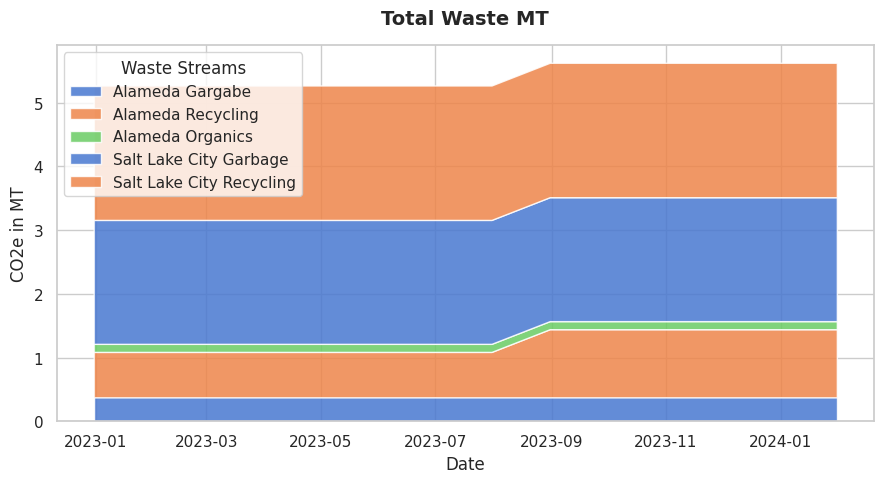

In [ ]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_waste['date'],
    merged_waste['al_total_monthly_garbage_MT'], merged_waste["al_total_monthly_recycling_MT"],merged_waste["al_monthly_organics_MT"], merged_waste['slc_total_monthly_garbage_MT'], merged_waste["slc_total_monthly_recycling_MT"],
    labels=['Alameda Gargabe','Alameda Recycling', 'Alameda Organics', 'Salt Lake City Garbage', 'Salt Lake City Recycling'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Waste MT", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Waste Streams", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/waste_MT_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()

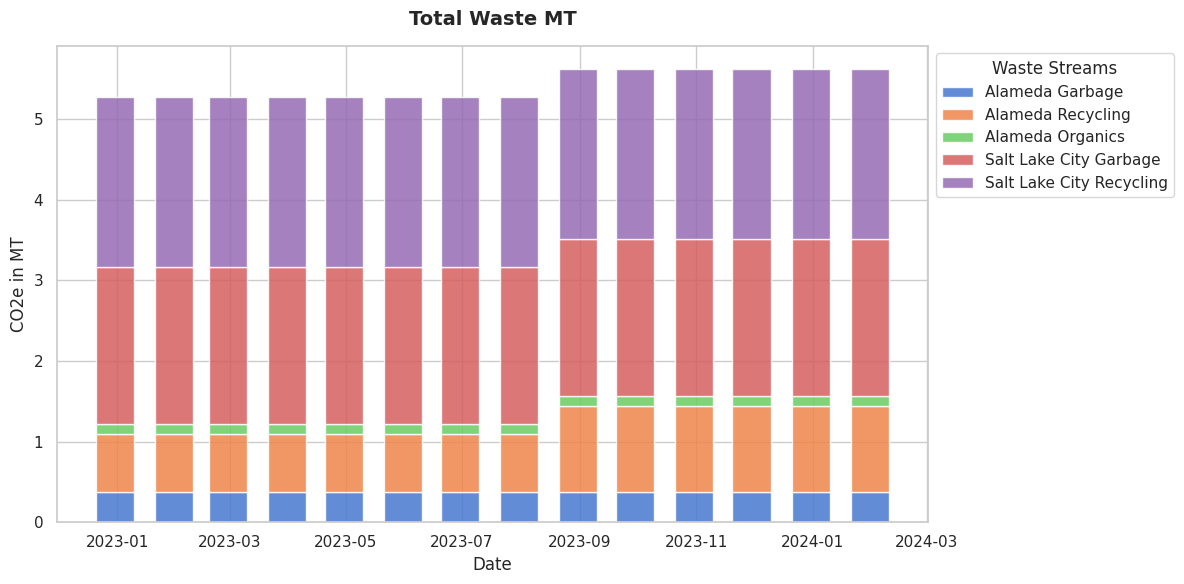

In [ ]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 2. Extract the data columns for cleaner referencing
x = merged_waste['date']
al_garb = merged_waste['al_total_monthly_garbage_MT']
al_rec = merged_waste["al_total_monthly_recycling_MT"]
al_org = merged_waste["al_monthly_organics_MT"]
slc_garb = merged_waste['slc_total_monthly_garbage_MT']
slc_rec = merged_waste["slc_total_monthly_recycling_MT"]

# 3. Choose a Seaborn color palette (requires 5 colors for 5 streams)
colors = sns.color_palette("muted", 5)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Assuming monthly data, make each bar 20 days wide to fill the gap
bar_width = 20

b1 = ax.bar(x, al_garb, width=bar_width, label='Alameda Garbage', color=colors[0], alpha=0.85)
b2 = ax.bar(x, al_rec, bottom=al_garb, width=bar_width, label='Alameda Recycling', color=colors[1], alpha=0.85)
b3 = ax.bar(x, al_org, bottom=al_garb + al_rec, width=bar_width, label='Alameda Organics', color=colors[2], alpha=0.85)
b4 = ax.bar(x, slc_garb, bottom=al_garb + al_rec + al_org, width=bar_width, label='Salt Lake City Garbage', color=colors[3], alpha=0.85)
b5 = ax.bar(x, slc_rec, bottom=al_garb + al_rec + al_org + slc_garb, width=bar_width, label='Salt Lake City Recycling', color=colors[4], alpha=0.85)

# 5. Clean up annotations and formatting
ax.set_title("Total Waste MT", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Waste Streams", loc='upper left', bbox_to_anchor=(1, 1)) # Moved slightly outside for clarity

plt.tight_layout()
plt.savefig(
    "outputs/waste_MT_stacked_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
file_path = 'outputs/MJs_and_waste.xlsx'

# Open the writer cleanly
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    # Use your ACTUAL variable names here:
    merged_dk.to_excel(writer, sheet_name='Natural Gas in MJs', index=False)
    df_electricity_mj.to_excel(writer, sheet_name='Electricity in MJs', index=False)
    merged_waste.to_excel(writer, sheet_name='Waste in MT', index=False)



wb = openpyxl.load_workbook(file_path)

# Palettes: Muted Forest Green / Sustainability theme
header_fill = PatternFill(start_color="2D5A27", end_color="2D5A27", fill_type="solid")
header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
data_font = Font(name="Arial", size=10)
bold_font = Font(name="Arial", size=10, bold=True)
thin_border = Border(
    left=Side(style='thin', color='E0E0E0'),
    right=Side(style='thin', color='E0E0E0'),
    top=Side(style='thin', color='E0E0E0'),
    bottom=Side(style='thin', color='E0E0E0')
)
zebra_fill = PatternFill(start_color="F7F9F6", end_color="F7F9F6", fill_type="solid")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    ws.views.sheetView[0].showGridLines = True

    # Format Headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # Format Data Rows
    max_row = ws.max_row
    max_col = ws.max_column

    for row in range(2, max_row + 1):
        is_zebra = (row % 2 == 0)
        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = data_font
            cell.border = thin_border
            if is_zebra:
                cell.fill = zebra_fill

            # Alignments & Number formats
            if col == 1:
                cell.alignment = Alignment(horizontal="center")
            else:
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '#,##0.00'

    # Add a Total Row
    total_row_idx = max_row + 1
    ws.cell(row=total_row_idx, column=1, value="Total").font = bold_font
    ws.cell(row=total_row_idx, column=1).alignment = Alignment(horizontal="center")
    ws.cell(row=total_row_idx, column=1).border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    for col in range(2, max_col + 1):
        col_letter = get_column_letter(col)
        total_cell = ws.cell(row=total_row_idx, column=col)
        total_cell.value = f"=SUM({col_letter}2:{col_letter}{max_row})"
        total_cell.font = bold_font
        total_cell.alignment = Alignment(horizontal="right")
        total_cell.number_format = '#,##0.00'
        total_cell.border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    # Autofit columns
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_path)
print("Successfully generated and styled Excel spreadsheet.")

Successfully generated and styled Excel spreadsheet.


### CO2 conversion

In [ ]:
waste_co2_factors_2022 = ghg_2022.iloc[398:459, 2:9]
first_row = waste_co2_factors_2022.iloc[0].tolist()
first_row
waste_co2_factors_2022 = waste_co2_factors_2022.rename(columns={"Unnamed: 2":'Material', "Unnamed: 3":"Recycled", "Unnamed: 4":"Landfilled",
                                                      "Unnamed: 5":"Combusted", "Unnamed: 6":"Composted",
                                                      "Unnamed: 7":'Anaerobically Digested (Dry Digestate with Curing)',
                                                      "Unnamed: 8":'Anaerobically Digested (Wet  Digestate with Curing)'})
waste_co2_factors_2022 = waste_co2_factors_2022.iloc[1:]

In [ ]:
waste_co2_factors_2022

,Material,Recycled,Landfilled,Combusted,Composted,Anaerobically Digested (Dry Digestate with Curing),Anaerobically Digested (Wet Digestate with Curing)
399,Aluminum Cans,0.06,0.02,0.01,NaN,NaN,NaN
400,Aluminum Ingot,0.04,0.02,0.01,NaN,NaN,NaN
401,Steel Cans,0.32,0.02,0.01,NaN,NaN,NaN
402,Copper Wire,0.18,0.02,0.01,NaN,NaN,NaN
403,Glass,0.05,0.02,0.01,NaN,NaN,NaN
404,HDPE,0.21,0.02,2.8,NaN,NaN,NaN
405,LDPE,NaN,0.02,2.8,NaN,NaN,NaN
406,PET,0.23,0.02,2.05,NaN,NaN,NaN
407,LLDPE,NaN,0.02,2.8,NaN,NaN,NaN
408,PP,NaN,0.02,2.8,NaN,NaN,NaN


In [ ]:
waste_co2_factors_2023 = ghg_2023.iloc[416:477, 2:9]
first_row = waste_co2_factors_2023.iloc[0].tolist()
first_row
waste_co2_factors_2023 = waste_co2_factors_2023.rename(columns={"Unnamed: 2":'Material', "Unnamed: 3":"Recycled", "Unnamed: 4":"Landfilled",
                                                      "Unnamed: 5":"Combusted", "Unnamed: 6":"Composted",
                                                      "Unnamed: 7":'Anaerobically Digested (Dry Digestate with Curing)',
                                                      "Unnamed: 8":'Anaerobically Digested (Wet  Digestate with Curing)'})
waste_co2_factors_2023 = waste_co2_factors_2023.iloc[1:]

In [ ]:
waste_co2_factors_2023

,Material,Recycled,Landfilled,Combusted,Composted,Anaerobically Digested (Dry Digestate with Curing),Anaerobically Digested (Wet Digestate with Curing)
417,Aluminum Cans,0.06,0.02,0.01,NaN,NaN,NaN
418,Aluminum Ingot,0.04,0.02,0.01,NaN,NaN,NaN
419,Steel Cans,0.32,0.02,0.01,NaN,NaN,NaN
420,Copper Wire,0.18,0.02,0.01,NaN,NaN,NaN
421,Glass,0.05,0.02,0.01,NaN,NaN,NaN
422,HDPE,0.21,0.02,2.8,NaN,NaN,NaN
423,LDPE,NaN,0.02,2.8,NaN,NaN,NaN
424,PET,0.23,0.02,2.05,NaN,NaN,NaN
425,LLDPE,NaN,0.02,2.8,NaN,NaN,NaN
426,PP,NaN,0.02,2.8,NaN,NaN,NaN


In [ ]:
waste_co2_factors_2022.to_excel('outputs/waste_co2_factors_2022.xlsx', index=False)

In [ ]:
# 1. Find the row where the first column equals "Mixed Organics"
# (Replace waste_co2_factors_2023.columns[0] with the actual column name if it has one)
mixed_org_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed Organics"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
organics_co2_factor_2022 = mixed_org_row_2022.iloc[:, 4:5]
organics_co2_factor_2022

,Composted
439,0.17


In [ ]:
# 1. Find the row where the first column equals "Mixed MSW"
mixed_gar_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed MSW"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
garbage_co2_factor_2022 = mixed_gar_row_2022.iloc[:, 2:3]
garbage_co2_factor_2022

,Landfilled
440,0.52


In [ ]:

# 1. Find the row where the first column equals "Mixed Recyclables"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_rec_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed Recyclables"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
recyclables_co2_factor_2022 = mixed_rec_row_2022.iloc[:, 1:2]
recyclables_co2_factor_2022

,Recycled
437,0.09


In [ ]:
# 1. Find the row where the first column equals "Mixed Organics"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_org_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed Organics"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
organics_co2_factor_2023 = mixed_org_row_2023.iloc[:, 4:5]
organics_co2_factor_2023

,Composted
457,0.17


In [ ]:
# 1. Find the row where the first column equals "Mixed MSW"
mixed_gar_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed MSW"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
garbage_co2_factor_2023 = mixed_gar_row_2023.iloc[:, 2:3]
garbage_co2_factor_2023

,Landfilled
458,0.52


In [ ]:

# 1. Find the row where the first column equals "Mixed Recyclables"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_rec_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed Recyclables"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
recyclables_co2_factor_2023 = mixed_rec_row_2023.iloc[:, 1:2]
recyclables_co2_factor_2023

,Recycled
455,0.09


In [ ]:
# Convert your factors into single numeric values (floats)
# If they are still DataFrames, grab the very first element:
garbage_co2_val_2022 = float(garbage_co2_factor_2022.values.flatten()[0])
recyclables_co2_val_2022 = float(recyclables_co2_factor_2022.values.flatten()[0])
organics_co2_val_2022 = float(organics_co2_factor_2022.values.flatten()[0])

garbage_co2_val_2023 = float(garbage_co2_factor_2023.values.flatten()[0])
recyclables_co2_val_2023 = float(recyclables_co2_factor_2023.values.flatten()[0])
organics_co2_val_2023 = float(organics_co2_factor_2023.values.flatten()[0])

if  '2022' in merged_waste["date"]:
    merged_waste["al_total_monthly_garbage_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["al_total_monthly_recycling_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * recyclables_co2_val_2022
    merged_waste["al_total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2022

    merged_waste["slc_total_monthly_garbage_co2e"] = merged_waste["slc_total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["slc_total_monthly_recycling_co2e"] = merged_waste["slc_total_monthly_recycling_MT"] * recyclables_co2_val_2022

    merged_waste["total_monthly_garbage_co2e"] = merged_waste["total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["total_monthly_recycling_co2e"] = merged_waste["total_monthly_recycling_MT"] * recyclables_co2_val_2022
    merged_waste["total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2022
    merged_waste["Total_waste_co2e"] = merged_waste["total_monthly_recycling_co2e"] + merged_waste["total_monthly_organics_co2e"] + merged_waste["total_monthly_garbage_co2e"]



else:
    merged_waste["al_total_monthly_garbage_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["al_total_monthly_recycling_co2e"] = merged_waste["al_total_monthly_recycling_MT"] * recyclables_co2_val_2023
    merged_waste["al_total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2023

    merged_waste["slc_total_monthly_garbage_co2e"] = merged_waste["slc_total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["slc_total_monthly_recycling_co2e"] = merged_waste["slc_total_monthly_recycling_MT"] * recyclables_co2_val_2023

    merged_waste["total_monthly_garbage_co2e"] = merged_waste["total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["total_monthly_recycling_co2e"] = merged_waste["total_monthly_recycling_MT"] * recyclables_co2_val_2023
    merged_waste["total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2023

    merged_waste["Total_waste_co2e"] = merged_waste["total_monthly_recycling_co2e"] + merged_waste["total_monthly_organics_co2e"] + merged_waste["total_monthly_garbage_co2e"]

merged_waste



,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_organics_MT,al_total_monthly_garbage_co2e,al_total_monthly_recycling_co2e,al_total_monthly_organics_co2e,slc_total_monthly_garbage_co2e,slc_total_monthly_recycling_co2e,total_monthly_garbage_co2e,total_monthly_recycling_co2e,total_monthly_organics_co2e,Total_waste_co2e
0,2022-12-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
1,2023-01-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
2,2023-02-28,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
3,2023-03-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
4,2023-04-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
5,2023-05-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
6,2023-06-30,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
7,2023-07-31,6.0,6.0,0.475308,26.1,26.10,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.064174,0.021524,1.011647,0.189956,1.861197,0.469114,0.021524,2.351834
8,2023-08-31,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.096261,0.021524,1.011647,0.189956,1.861197,0.608693,0.021524,2.491413
9,2023-09-30,6.0,9.0,0.475308,26.1,39.15,2.067592,7.0,4.0,31.08,...,0.126609,0.195299,0.096261,0.021524,1.011647,0.189956,1.861197,0.608693,0.021524,2.491413


In [ ]:
file_path = 'outputs/waste.xlsx'

# Open the writer cleanly
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    # Use your ACTUAL variable names here:
    merged_waste.to_excel(writer, sheet_name='Waste in MT', index=False)



wb = openpyxl.load_workbook(file_path)

# Palettes: Muted Forest Green / Sustainability theme
header_fill = PatternFill(start_color="2D5A27", end_color="2D5A27", fill_type="solid")
header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
data_font = Font(name="Arial", size=10)
bold_font = Font(name="Arial", size=10, bold=True)
thin_border = Border(
    left=Side(style='thin', color='E0E0E0'),
    right=Side(style='thin', color='E0E0E0'),
    top=Side(style='thin', color='E0E0E0'),
    bottom=Side(style='thin', color='E0E0E0')
)
zebra_fill = PatternFill(start_color="F7F9F6", end_color="F7F9F6", fill_type="solid")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    ws.views.sheetView[0].showGridLines = True

    # Format Headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # Format Data Rows
    max_row = ws.max_row
    max_col = ws.max_column

    for row in range(2, max_row + 1):
        is_zebra = (row % 2 == 0)
        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = data_font
            cell.border = thin_border
            if is_zebra:
                cell.fill = zebra_fill

            # Alignments & Number formats
            if col == 1:
                cell.alignment = Alignment(horizontal="center")
            else:
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '#,##0.00'

    # Add a Total Row
    total_row_idx = max_row + 1
    ws.cell(row=total_row_idx, column=1, value="Total").font = bold_font
    ws.cell(row=total_row_idx, column=1).alignment = Alignment(horizontal="center")
    ws.cell(row=total_row_idx, column=1).border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    for col in range(2, max_col + 1):
        col_letter = get_column_letter(col)
        total_cell = ws.cell(row=total_row_idx, column=col)
        total_cell.value = f"=SUM({col_letter}2:{col_letter}{max_row})"
        total_cell.font = bold_font
        total_cell.alignment = Alignment(horizontal="right")
        total_cell.number_format = '#,##0.00'
        total_cell.border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    # Autofit columns
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_path)
print("Successfully generated and styled Excel spreadsheet.")

Successfully generated and styled Excel spreadsheet.


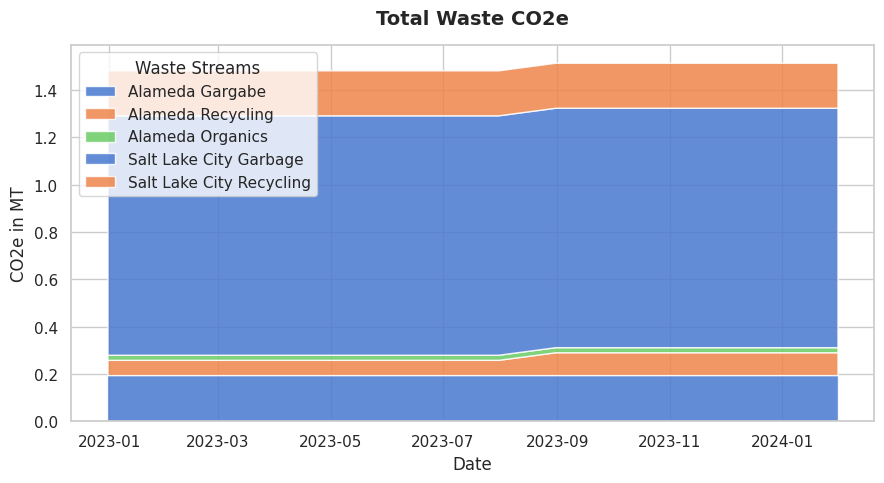

In [ ]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_waste['date'],
    merged_waste['al_total_monthly_garbage_co2e'], merged_waste["al_total_monthly_recycling_co2e"],merged_waste["al_total_monthly_organics_co2e"], merged_waste['slc_total_monthly_garbage_co2e'], merged_waste["slc_total_monthly_recycling_co2e"],
    labels=['Alameda Gargabe','Alameda Recycling', 'Alameda Organics', 'Salt Lake City Garbage', 'Salt Lake City Recycling'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Waste CO2e", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Waste Streams", loc='upper left')

plt.tight_layout()
plt.savefig(
    "outputs/waste_co2e_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)
plt.show()


# Total Scope 1, Scope2, & Scope 3 emissions

In [ ]:
file_path = 'outputs/carbon_footprint.xlsx'

# Open the writer cleanly
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    # Use your ACTUAL variable names here:
    ghg_co2e_2023.to_excel(writer, sheet_name='2023 Scope 1', index=False)
    df_electricity.to_excel(writer, sheet_name='2023 Scope 2', index=False)
    merged_waste.to_excel(writer, sheet_name='2023 Scope 3', index=False)



wb = openpyxl.load_workbook(file_path)

# Palettes: Muted Forest Green / Sustainability theme
header_fill = PatternFill(start_color="2D5A27", end_color="2D5A27", fill_type="solid")
header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
data_font = Font(name="Arial", size=10)
bold_font = Font(name="Arial", size=10, bold=True)
thin_border = Border(
    left=Side(style='thin', color='E0E0E0'),
    right=Side(style='thin', color='E0E0E0'),
    top=Side(style='thin', color='E0E0E0'),
    bottom=Side(style='thin', color='E0E0E0')
)
zebra_fill = PatternFill(start_color="F7F9F6", end_color="F7F9F6", fill_type="solid")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    ws.views.sheetView[0].showGridLines = True

    # Format Headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # Format Data Rows
    max_row = ws.max_row
    max_col = ws.max_column

    for row in range(2, max_row + 1):
        is_zebra = (row % 2 == 0)
        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = data_font
            cell.border = thin_border
            if is_zebra:
                cell.fill = zebra_fill

            # Alignments & Number formats
            if col == 1:
                cell.alignment = Alignment(horizontal="center")
            else:
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '#,##0.00'

    # Add a Total Row
    total_row_idx = max_row + 1
    ws.cell(row=total_row_idx, column=1, value="Total").font = bold_font
    ws.cell(row=total_row_idx, column=1).alignment = Alignment(horizontal="center")
    ws.cell(row=total_row_idx, column=1).border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    for col in range(2, max_col + 1):
        col_letter = get_column_letter(col)
        total_cell = ws.cell(row=total_row_idx, column=col)
        total_cell.value = f"=SUM({col_letter}2:{col_letter}{max_row})"
        total_cell.font = bold_font
        total_cell.alignment = Alignment(horizontal="right")
        total_cell.number_format = '#,##0.00'
        total_cell.border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    # Autofit columns
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_path)
print("Successfully generated and styled Excel spreadsheet.")

Successfully generated and styled Excel spreadsheet.


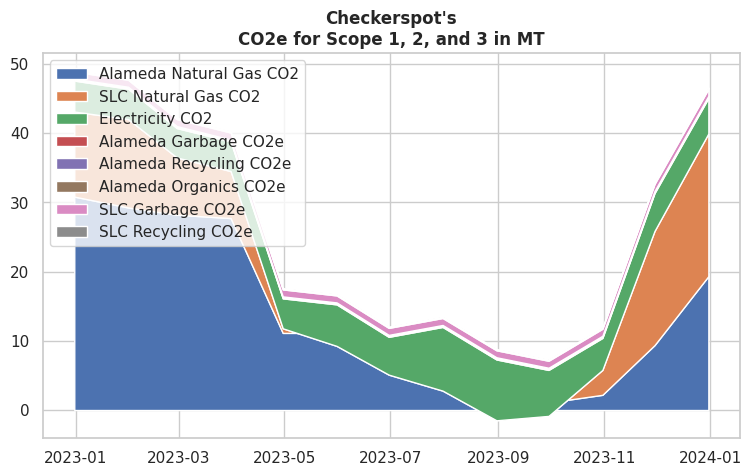

In [ ]:
y4 = merged_waste['al_total_monthly_garbage_co2e'].values[:13]
y5 = merged_waste["al_total_monthly_recycling_co2e"].values[:13]
y6 = merged_waste["al_total_monthly_organics_co2e"].values[:13]
y7 = merged_waste['slc_total_monthly_garbage_co2e'].values[:13]
y8 = merged_waste["slc_total_monthly_recycling_co2e"].values[:13]


# 1. Your plotting code
fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(df_electricity['date'],
             ghg_co2e_2023['al_DK_co2'], ghg_co2e_2023_offset,df_electricity['co2_MT_slc'], y4,y5,y6,y7,y8,
             labels=['Alameda Natural Gas CO2', "SLC Natural Gas CO2",'Electricity CO2', 'Alameda Garbage CO2e',"Alameda Recycling CO2e",
                     "Alameda Organics CO2e",'SLC Garbage CO2e',"SLC Recycling CO2e"])

ax.set_title("company_xyz's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# 2. SAVE FIRST
plt.savefig('outputs/co2e_emissions_stackplot_scope123_al_slc_waste_streams.png', dpi=300, bbox_inches='tight')

# 3. SHOW SECOND
plt.show()

In [ ]:
import pandas as pd

# 1. Create a clean date series formatted nicely for charting (e.g., "Dec-22")
clean_dates = pd.to_datetime(df_electricity['date'].values[:13]).strftime('%b-%y')


# 2. Combine all sliced data streams into a single dictionary
data_dict = {
    'Date': clean_dates,
    'Alameda_Natural_Gas_CO2': ghg_co2e_2023['al_DK_co2'].values[:13],
    'SLC_Natural_Gas_CO2': ghg_co2e_2023_offset.values[:13] if hasattr(ghg_co2e_2023_offset, 'values') else ghg_co2e_2023_offset[:13],
    'Electricity_CO2': df_electricity['co2_MT_slc'].values[:13],
    'Alameda_Garbage_CO2e': merged_waste['al_total_monthly_garbage_co2e'].values[:13],
    'Alameda_Recycling_CO2e': merged_waste["al_total_monthly_recycling_co2e"].values[:13],
    'Alameda_Organics_CO2e': merged_waste["al_total_monthly_organics_co2e"].values[:13],
    'SLC_Garbage_CO2e': merged_waste['slc_total_monthly_garbage_co2e'].values[:13],
    'SLC_Recycling_CO2e': merged_waste["slc_total_monthly_recycling_co2e"].values[:13]
}

# 3. Initialize the consolidated DataFrame
co2e_tot_waste_streams = pd.DataFrame(data_dict)

# 4. Optional: Handle any potential NaN values by converting them to 0
co2e_tot_waste_streams = co2e_tot_waste_streams.fillna(0)

# Preview the combined data frame
print(co2e_tot_waste_streams.head())
co2e_tot_waste_streams.columns.tolist()

     Date  Alameda_Natural_Gas_CO2  SLC_Natural_Gas_CO2  Electricity_CO2  \
0  Dec-22                30.838472            12.283390         4.477506   
1  Jan-23                29.262590            12.771542         4.388850   
2  Feb-23                28.222614             8.266748         4.250106   
3  Mar-23                27.734462             6.791680         4.275725   
4  Apr-23                11.142600             0.663250         4.330128   

   Alameda_Garbage_CO2e  Alameda_Recycling_CO2e  Alameda_Organics_CO2e  \
0              0.195299                0.064174               0.021524   
1              0.195299                0.064174               0.021524   
2              0.195299                0.064174               0.021524   
3              0.195299                0.064174               0.021524   
4              0.195299                0.064174               0.021524   

   SLC_Garbage_CO2e  SLC_Recycling_CO2e  
0          1.011647            0.189956  
1          1.0

['Date',
 'Alameda_Natural_Gas_CO2',
 'SLC_Natural_Gas_CO2',
 'Electricity_CO2',
 'Alameda_Garbage_CO2e',
 'Alameda_Recycling_CO2e',
 'Alameda_Organics_CO2e',
 'SLC_Garbage_CO2e',
 'SLC_Recycling_CO2e']

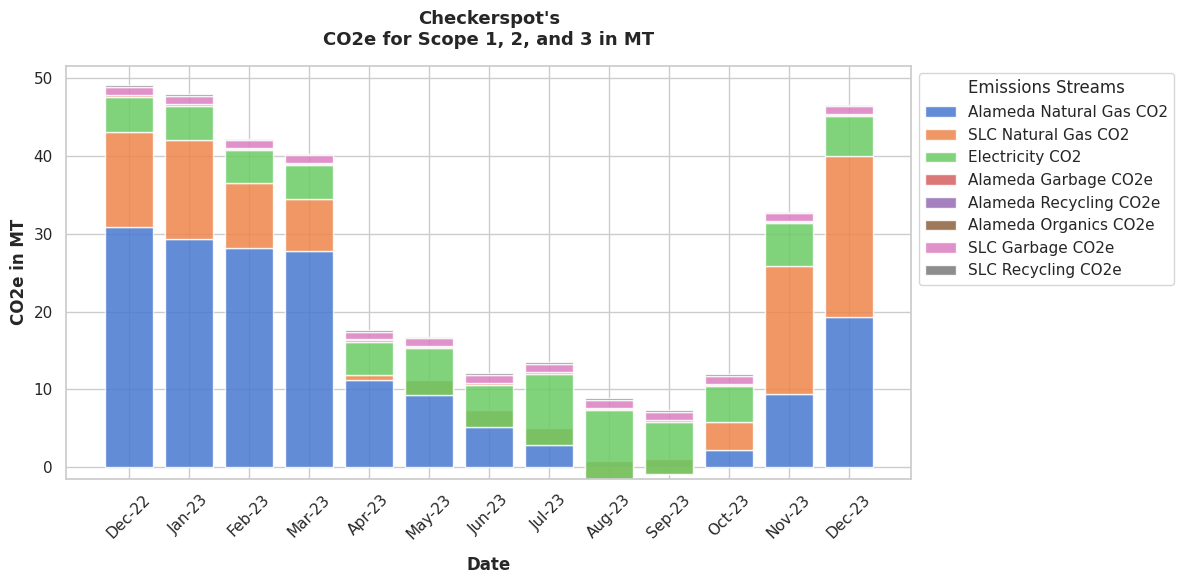

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Activate Seaborn styling
sns.set_theme(style="whitegrid")

# Extract categorical x-axis labels
x = co2e_tot_waste_streams['Date']

# Extract data streams (Fixed the trailing comma syntax error on y1)
y1 = co2e_tot_waste_streams['Alameda_Natural_Gas_CO2']
y2 = co2e_tot_waste_streams['SLC_Natural_Gas_CO2']
y3 = co2e_tot_waste_streams['Electricity_CO2']
y4 = co2e_tot_waste_streams['Alameda_Garbage_CO2e']
y5 = co2e_tot_waste_streams['Alameda_Recycling_CO2e']
y6 = co2e_tot_waste_streams['Alameda_Organics_CO2e']
y7 = co2e_tot_waste_streams['SLC_Garbage_CO2e']
y8 = co2e_tot_waste_streams['SLC_Recycling_CO2e']

# Generate a color palette for 8 distinct streams
colors = sns.color_palette("muted", 8)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Use a proportional fractional width (e.g., 0.6) for text-based categories
bar_width = 0.8

# Plot bars with sequential stacking using the corrected width
b1 = ax.bar(x, y1, width=bar_width, label='Alameda Natural Gas CO2', color=colors[0], alpha=0.85)
b2 = ax.bar(x, y2, bottom=y1, width=bar_width, label='SLC Natural Gas CO2', color=colors[1], alpha=0.85)
b3 = ax.bar(x, y3, bottom=y1+y2, width=bar_width, label='Electricity CO2', color=colors[2], alpha=0.85)
b4 = ax.bar(x, y4, bottom=y1+y2+y3, width=bar_width, label='Alameda Garbage CO2e', color=colors[3], alpha=0.85)
b5 = ax.bar(x, y5, bottom=y1+y2+y3+y4, width=bar_width, label='Alameda Recycling CO2e', color=colors[4], alpha=0.85)
b6 = ax.bar(x, y6, bottom=y1+y2+y3+y4+y5, width=bar_width, label='Alameda Organics CO2e', color=colors[5], alpha=0.85)
b7 = ax.bar(x, y7, bottom=y1+y2+y3+y4+y5+y6, width=bar_width, label='SLC Garbage CO2e', color=colors[6], alpha=0.85)
b8 = ax.bar(x, y8, bottom=y1+y2+y3+y4+y5+y6+y7, width=bar_width, label='SLC Recycling CO2e', color=colors[7], alpha=0.85)

# Formatting labels and title
ax.set_title("company_xyz's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontweight='bold', labelpad=10)
ax.set_ylabel("CO2e in MT", fontweight='bold')

# Rotate x-axis labels slightly for better breathing room
plt.xticks(rotation=45)

# Place legend outside to the right so it doesn't overlap the 8 layers
ax.legend(title="Emissions Streams", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save and show
plt.savefig('outputs/co2e_emissions_stacked_bar_waste_streams_scope123.png', dpi=300, bbox_inches='tight')
plt.show()

#The Green therms offset from SLC Natural Gas does something weird and pulls down the electricity
#that's why you see an orange and green mix


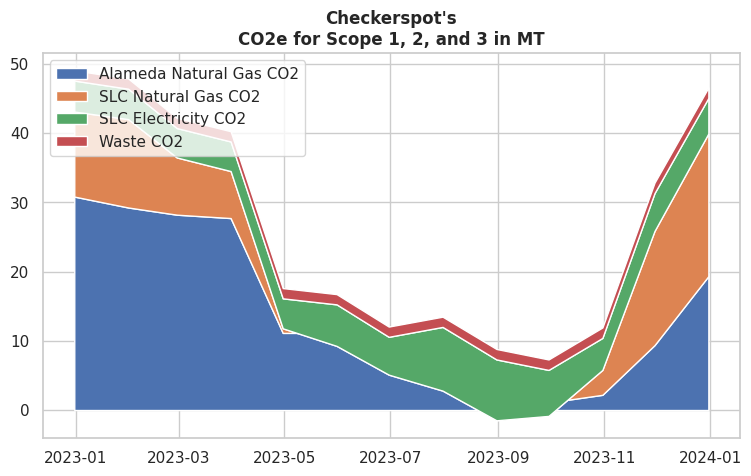

In [ ]:
y4 = merged_waste['al_total_monthly_garbage_co2e'].values[:13]
y5 = merged_waste["al_total_monthly_recycling_co2e"].values[:13]
y6 = merged_waste["al_total_monthly_organics_co2e"].values[:13]
y7 = merged_waste['slc_total_monthly_garbage_co2e'].values[:13]
y8 = merged_waste["slc_total_monthly_recycling_co2e"].values[:13]
waste= y4+y5+y6+y7+y8

# 1. Your plotting code
fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(df_electricity['date'],
             ghg_co2e_2023['al_DK_co2'], ghg_co2e_2023_offset,df_electricity['co2_MT_slc'], waste,
             labels=['Alameda Natural Gas CO2', "SLC Natural Gas CO2",'SLC Electricity CO2', 'Waste CO2'])

ax.set_title("company_xyz's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# 2. SAVE FIRST
plt.savefig('outputs/co2e_emissions_stackplot_scope_123_total_waste.png', dpi=300, bbox_inches='tight')

# 3. SHOW SECOND
plt.show()

In [ ]:
# 1. Create a clean date series formatted nicely for charting (e.g., "Dec-22")
clean_dates = pd.to_datetime(df_electricity['date'].values[:13]).strftime('%b-%y')


# 2. Combine all sliced data streams into a single dictionary
data_dict = {
    'Date': clean_dates,
    'Alameda_Natural_Gas_CO2': ghg_co2e_2023['al_DK_co2'].values[:13],
    'SLC_Natural_Gas_CO2': ghg_co2e_2023_offset.values[:13] if hasattr(ghg_co2e_2023_offset, 'values') else ghg_co2e_2023_offset[:13],
    'Electricity_CO2': df_electricity['co2_MT_slc'].values[:13],
    'Alameda_Garbage_CO2e': merged_waste['al_total_monthly_garbage_co2e'].values[:13],
    'Alameda_Recycling_CO2e': merged_waste["al_total_monthly_recycling_co2e"].values[:13],
    'Alameda_Organics_CO2e': merged_waste["al_total_monthly_organics_co2e"].values[:13],
    'SLC_Garbage_CO2e': merged_waste['slc_total_monthly_garbage_co2e'].values[:13],
    'SLC_Recycling_CO2e': merged_waste["slc_total_monthly_recycling_co2e"].values[:13]
}

# 3. Initialize the consolidated DataFrame
co2e_tot_waste_streams = pd.DataFrame(data_dict)

# 4. Optional: Handle any potential NaN values by converting them to 0
co2e_tot_waste_streams = co2e_tot_waste_streams.fillna(0)

# Preview the combined data frame
print(co2e_tot_waste_streams.head())
co2e_tot_waste_streams.columns.tolist()

     Date  Alameda_Natural_Gas_CO2  SLC_Natural_Gas_CO2  Electricity_CO2  \
0  Dec-22                30.838472            12.283390         4.477506   
1  Jan-23                29.262590            12.771542         4.388850   
2  Feb-23                28.222614             8.266748         4.250106   
3  Mar-23                27.734462             6.791680         4.275725   
4  Apr-23                11.142600             0.663250         4.330128   

   Alameda_Garbage_CO2e  Alameda_Recycling_CO2e  Alameda_Organics_CO2e  \
0              0.195299                0.064174               0.021524   
1              0.195299                0.064174               0.021524   
2              0.195299                0.064174               0.021524   
3              0.195299                0.064174               0.021524   
4              0.195299                0.064174               0.021524   

   SLC_Garbage_CO2e  SLC_Recycling_CO2e  
0          1.011647            0.189956  
1          1.0

['Date',
 'Alameda_Natural_Gas_CO2',
 'SLC_Natural_Gas_CO2',
 'Electricity_CO2',
 'Alameda_Garbage_CO2e',
 'Alameda_Recycling_CO2e',
 'Alameda_Organics_CO2e',
 'SLC_Garbage_CO2e',
 'SLC_Recycling_CO2e']

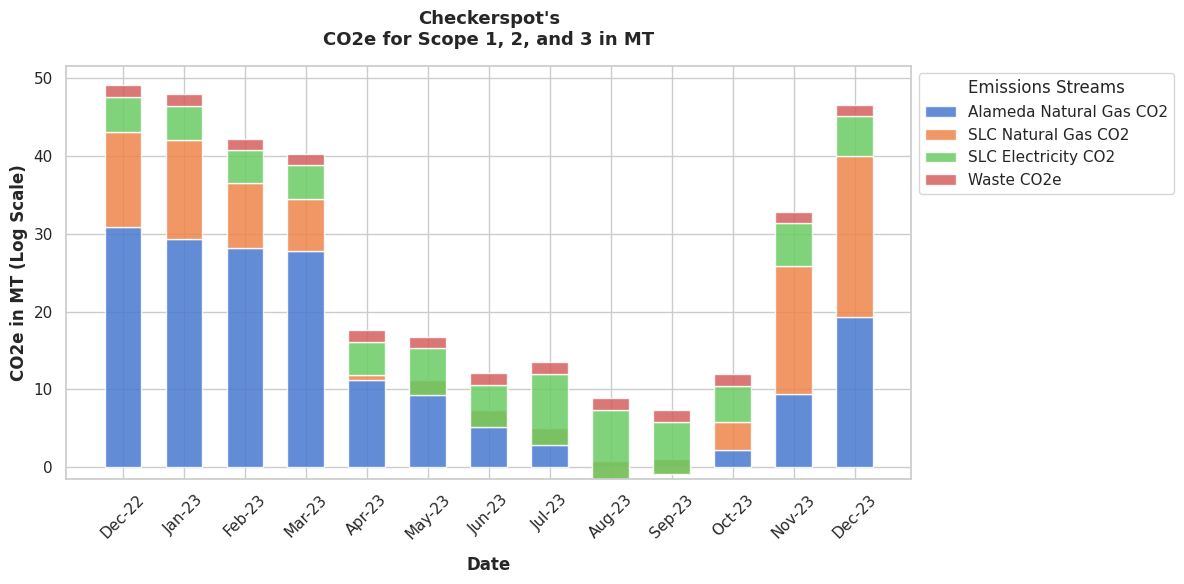

In [ ]:


# Activate Seaborn styling
sns.set_theme(style="whitegrid")

# Extract categorical x-axis labels
x = co2e_tot_waste_streams['Date']

# 1. Extract Energy Streams
y1 = co2e_tot_waste_streams['Alameda_Natural_Gas_CO2']
y2 = co2e_tot_waste_streams['SLC_Natural_Gas_CO2']
y3 = co2e_tot_waste_streams['Electricity_CO2']

# 2. Extract Waste Streams FIRST before adding them together
y4 = co2e_tot_waste_streams['Alameda_Garbage_CO2e']
y5 = co2e_tot_waste_streams['Alameda_Recycling_CO2e']
y6 = co2e_tot_waste_streams['Alameda_Organics_CO2e']
y7 = co2e_tot_waste_streams['SLC_Garbage_CO2e']
y8 = co2e_tot_waste_streams['SLC_Recycling_CO2e']

# 3. Sum the waste streams securely
waste = y4 + y5 + y6 + y7 + y8

# Generate a color palette for 4 distinct streams
colors = sns.color_palette("muted", 4)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.6

# Plot bars with sequential stacking
b1 = ax.bar(x, y1, width=bar_width, label='Alameda Natural Gas CO2', color=colors[0], alpha=0.85)
b2 = ax.bar(x, y2, bottom=y1, width=bar_width, label='SLC Natural Gas CO2', color=colors[1], alpha=0.85)
b3 = ax.bar(x, y3, bottom=y1+y2, width=bar_width, label='SLC Electricity CO2', color=colors[2], alpha=0.85)
b4 = ax.bar(x, waste, bottom=y1+y2+y3, width=bar_width, label='Waste CO2e', color=colors[3], alpha=0.85)


# Formatting labels and title
ax.set_title("company_xyz's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontweight='bold', labelpad=10)
ax.set_ylabel("CO2e in MT (Log Scale)", fontweight='bold')

# Rotate x-axis labels slightly for better breathing room
plt.xticks(rotation=45)

# Place legend outside to the right so it doesn't overlap
ax.legend(title="Emissions Streams", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save and show
plt.savefig('outputs/co2e_emissions_stacked_bar_1waste__scope123.png', dpi=300, bbox_inches='tight')
plt.show()
#The Green therms offset from SLC Natural Gas does something weird and pulls down the electricity
#that's why you see an orange and green mix


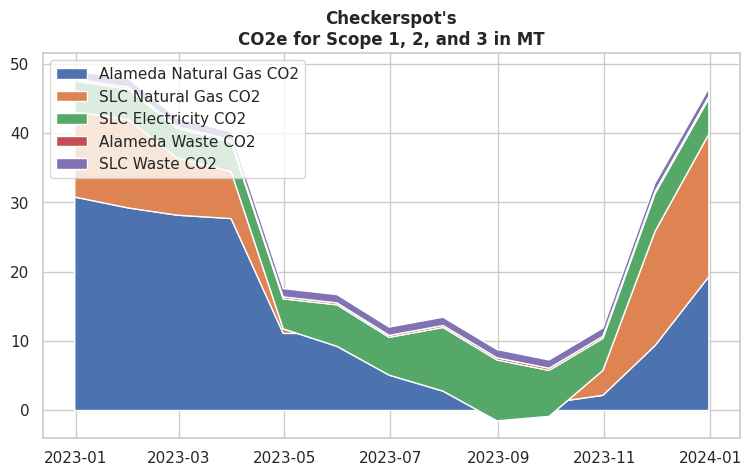

In [ ]:
y4 = merged_waste['al_total_monthly_garbage_co2e'].values[:13]
y5 = merged_waste["al_total_monthly_recycling_co2e"].values[:13]
y6 = merged_waste["al_total_monthly_organics_co2e"].values[:13]
y7 = merged_waste['slc_total_monthly_garbage_co2e'].values[:13]
y8 = merged_waste["slc_total_monthly_recycling_co2e"].values[:13]
al_waste = y4+y5+y6
slc_waste = y7+y8

# 1. Your plotting code
fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(df_electricity['date'],
             ghg_co2e_2023['al_DK_co2'], ghg_co2e_2023_offset,df_electricity['co2_MT_slc'], al_waste, slc_waste,
             labels=['Alameda Natural Gas CO2', "SLC Natural Gas CO2",'SLC Electricity CO2', 'Alameda Waste CO2', "SLC Waste CO2"])

ax.set_title("company_xyz's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# 2. SAVE FIRST
plt.savefig('outputs/co2e_emissions_stackplot_waste_al_slc.png', dpi=300, bbox_inches='tight')

# 3. SHOW SECOND
plt.show()